# DAF-17: Tune Without Touching the Test Days — TimeSeriesSplit Cross-Validation

## 📖 The story: Asha madam and the board-exam rule

Asha madam is the school coordinator. Every evening at 6 she decides: will the 600 children play outside tomorrow or not? Her model gives her tomorrow's PM2.5 number, and she turns it into "go out" or "stay in".

The model has **settings** she can change, like the knobs on a pressure cooker: `alpha` for Ridge, `max_depth` and `learning_rate` for the tree model. With default knobs, Ridge catches 109 of the 120 Poor days. She thinks: *"If I turn the knobs properly, it will catch more."*

So she turns a knob, checks the score on the **test days**, turns another knob, checks again. Twenty times. She keeps the best.

Sharma sir, the old maths teacher, laughs when he hears. *"Beta, this is a student who saw the board paper in advance and planned her study around it. She scores 95, but she is not a 95-marks student. She is a student who saw the paper. Good students write mock tests during the year, and in the right order: first Chapter 1 to 3, then test on Chapter 4. Never the Chapter 4 test after reading Chapter 5. That is cheating."*

Asha madam's 130 test days are the board paper. She has looked at it twenty times. It cannot tell her the truth any more.

## 🎯 The exact problem

> **How do we choose the best settings for the model, without ever looking at the test days, and without the mock tests mixing future days into the past?**

The answer is two tools. **`TimeSeriesSplit`** gives mock tests in the right order. **`RandomizedSearchCV`** tries many settings on those mock tests. The settings are written down before the board paper (the test days) is opened in DAF-18.

The pictures for this story are in `17_visual_walkthrough.ipynb`.

## What this ticket is about

Two changes to how we choose settings. The features and the question do not change.

```text
Before                                     After
settings = defaults                        settings chosen by cross-validation
(or chosen by looking at the test score)   on the 251 TRAIN days only
one score per model                        five scores per setting, averaged
```

The test period (130 days, from 1 Mar 2026) is not opened in this ticket. It is opened once, in DAF-18, with the settings frozen here.

## The new ideas

| Idea | One line | Where it comes from |
|---|---|---|
| Cross-validation | Cut the train days into pieces, fit on some, score on the next, repeat, average | sklearn |
| `TimeSeriesSplit` | The cut keeps time order: each fold trains on earlier rows, validates on the rows right after | `sklearn.model_selection` |
| Hyper-parameter | A setting you choose before fitting (`alpha`, `max_depth`, …). The model does not learn it | |
| `RandomizedSearchCV` | Try a fixed number of random settings, score each with cross-validation, keep the best | `sklearn.model_selection` |
| Frozen config | The chosen model and settings written to a file before DAF-18 | `models/final_config.json` |

Ordinary `KFold` with shuffling mixes future days into the training set, so it is not used here. The pictures are in `17_visual_walkthrough.ipynb`.

## What we search

| Model | Settings worth searching |
|---|---|
| Ridge | `alpha` |
| HistGradientBoosting | `learning_rate`, `max_depth`, `min_samples_leaf`, `max_iter` |
| RandomForest | `max_depth`, `min_samples_leaf`, `max_features` |

We tune **the best linear model and the best tree model** from DAF-15 and DAF-16. Ridge was best in DAF-16. Which tree model to carry forward is decided in Step 1, from the DAF-15 and DAF-16 scores, before any tuning runs.

Keep it small: 4 or 5 folds, a handful of settings per model, `scoring="neg_mean_absolute_error"`.

## Rules for this ticket

- **No test row anywhere.** The table is cut at 1 Mar 2026 and the test rows are dropped at the start. A code check shows it.
- **Preprocessing inside the fold.** The scaler is part of a `Pipeline`, so it is fitted on each fold's train rows only.
- **Compare by cross-validation score.** Tuned vs default is judged on the CV MAE, never on the test score.
- **Freeze before DAF-18.** The final model and settings go into a config file. After that, nothing changes.
- **Report honestly.** If tuning helps by a tiny amount, say so. The pictures already hint that Ridge may gain little.

## The plan, one step at a time

This is the proposed plan. Each step is added to this notebook only when we start it.

1. Rebuild the train table and prove no test row is in it. Choose the tree model to carry forward.
2. Build `TimeSeriesSplit` and plot the folds on a timeline.
3. Score both models at default settings with cross-validation. This is the baseline to beat.
4. Tune Ridge with `RandomizedSearchCV`.
5. Tune the tree model with `RandomizedSearchCV`.
6. Compare tuned vs default CV MAE for both models. Was it worth the complexity?
7. Choose the final model and write `models/final_config.json`.
8. Log the rows in `reports/experiments.csv`.

## Acceptance criteria (from the ticket)

- [ ] The fold plot shows every validation fold after its training fold
- [ ] No test row is used anywhere in this notebook — shown in code
- [ ] Tuned vs default CV MAE is reported for both models
- [ ] The final model and its settings are frozen before DAF-18 opens

## Explain back (answered at the end)

1. Why does `KFold` with shuffle cheat on this data?
2. How much did tuning help, and was it worth the complexity?

# Step 1 — Lock the board paper in the almirah

## 🎬 How we got here

Asha madam has heard Sharma sir. She will not tune on the test days any more. But before she writes a single mock test, Sharma sir asks one question:

> *"Beta, where is the board paper right now?"*

She opens her laptop. The table she has been using since DAF-14 has **all 381 days** in it, train days and test days together, in one big table. The board paper is lying open on the same desk as her notes.

## 😖 The problem

It is easy to say "I will not look at the test days". It is hard to keep the promise for the whole notebook. One careless line, like `table.describe()` or `table.tail()` or a scaler fitted on the full table, and the test days have leaked in. Nobody will notice, but the final score is no longer honest.

## 💡 The fix: lock it away, and prove it

Sharma sir's way: *"Do not trust your own willpower. Remove the paper from the room."*

1. **Load** the 381 days and build the four features (the same four features, fixed in DAF-14).
2. **Cut** at **1 March 2026**. Days before it are the study material (train). Days from it are the board paper (test).
3. **Count** the test days, then **throw them away** with `del`. After this line, there is no variable in this notebook that can hold a test row.
4. **Prove it** with three `assert` lines. If someone changes the code later and a test row sneaks in, the notebook stops with an error.

```text
381 days  ──cut at 1 Mar 2026──►  251 train days   → kept, used for ALL tuning
                              └►  130 test days    → counted (130), then deleted
```

**What "done" looks like:** one table called `train` with exactly 251 rows ending on 28 Feb 2026, a number `n_locked = 130`, and no other table in memory.

In [1]:
from pathlib import Path

import pandas as pd

from delhi_air.clean import add_rolling_features  # our own function from src/delhi_air/clean.py

# --- 1. Find the project's data folder (works from the repo root or from the project) ----
project_root = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "data/interim/daily_17.csv").is_file()
    or (candidate / "18_Projects/01_Delhi_Air_Forecast/data/interim/daily_17.csv").is_file()
)
data_root = (
    project_root / "data"
    if (project_root / "data/interim/daily_17.csv").is_file()
    else project_root / "18_Projects/01_Delhi_Air_Forecast/data"
)

# --- 2. Load the daily table: one row per Delhi calendar day ----------------------------
daily = pd.read_csv(data_root / "interim/daily_17.csv", parse_dates=["date"], index_col="date")
if daily.index.tz is not None:                              # drop the clock time, keep plain days
    daily.index = daily.index.tz_convert("Asia/Kolkata").tz_localize(None)
daily.index = daily.index.normalize()

# --- 3. Build the four features, keep only complete rows -------------------------------
feature_names = ["pm25_until_17", "mean_3", "mean_7", "mean_14"]   # fixed in DAF-14, not chosen again here
full_table = add_rolling_features(daily)[feature_names + ["target"]].dropna()

# --- 4. The cut: train rows stay, test rows are counted and then thrown away ------------
CUT_DATE = pd.Timestamp("2026-03-01")                       # the same cut date as DAF-06 to DAF-16
train = full_table.loc[full_table.index < CUT_DATE].copy()  # the only table this notebook will ever use
n_locked = len(full_table) - len(train)                     # we keep only the COUNT of the locked days
del daily, full_table                                       # no variable can hold a test row from here on

# --- 5. Proof that no test row is in the notebook ---------------------------------------
assert train.index.max() < CUT_DATE, "a test row got into the train table"
assert len(train) == 251 and n_locked == 130, "not the 251 / 130 split used in DAF-14 to DAF-16"
assert "daily" not in globals() and "full_table" not in globals(), "a table with test rows is still alive"

poor_days = int((train["target"] >= 91).sum())             # Poor = 91 or more (CPCB table, D-001)
print(f"train rows : {len(train)}  ({train.index.min().date()} to {train.index.max().date()})")
print(f"locked rows: {n_locked}  (from {CUT_DATE.date()}, counted but not kept)")
print(f"Poor days in train: {poor_days} of {len(train)}  ({poor_days / len(train):.0%})")
print("features   :", feature_names)
display(train.head(3).round(1))

train rows : 251  (2025-03-17 to 2026-02-28)
locked rows: 130  (from 2026-03-01, counted but not kept)
Poor days in train: 117 of 251  (47%)
features   : ['pm25_until_17', 'mean_3', 'mean_7', 'mean_14']


,pm25_until_17,mean_3,mean_7,mean_14,target
date,,,,,
2025-03-17,64.3,53.9,84.6,75.1,69.1
2025-03-18,76.5,46.3,79.5,75.5,76.7
2025-03-19,80.8,58.0,71.0,76.9,70.9


### What this code does, line by line

**Part 1 — find the data folder**

| Line | What it does |
|---|---|
| `from pathlib import Path` | `Path` is Python's way of handling file locations, so the same code works on Mac and Windows |
| `import pandas as pd` | pandas gives us tables (`DataFrame`). Like an Excel sheet you can program |
| `from delhi_air.clean import add_rolling_features` | Our **own** function from `src/delhi_air/clean.py`. It makes `mean_3`, `mean_7`, `mean_14` from the past days. We wrote and tested it in DAF-10 and DAF-14 |
| `project_root = next(candidate for candidate in (...) if ...)` | Start from the folder the notebook runs in, then go up one folder at a time. Stop at the first folder that contains `data/interim/daily_17.csv`. `next(...)` returns that first match |
| `data_root = ...` | If the data folder sits right inside `project_root`, use it. Otherwise look inside `18_Projects/01_Delhi_Air_Forecast/`. This lets the notebook run from the repo root **or** from the project folder, with no absolute path |

**Part 2 — load the daily table**

| Line | What it does |
|---|---|
| `pd.read_csv(..., parse_dates=["date"], index_col="date")` | Read the CSV. Turn the `date` column into real dates, and use it as the row label, so we can ask "all rows before 1 March" |
| `if daily.index.tz is not None:` | The dates may carry a time zone (`+05:30`). If they do, we handle it on the next line |
| `daily.index.tz_convert("Asia/Kolkata").tz_localize(None)` | First express the time in Delhi time, then drop the zone label. Result: a plain `2025-03-17 00:00`, not `2025-03-16 18:30 UTC` |
| `daily.index = daily.index.normalize()` | Set the clock part to midnight, so every row is exactly one calendar day |

**Part 3 — build the features**

| Line | What it does |
|---|---|
| `feature_names = [...]` | The four inputs of the model: today's PM2.5 until 5 pm, and the 3-day, 7-day and 14-day averages. Fixed in DAF-14, so tuning compares settings, not features |
| `add_rolling_features(daily)` | Adds the `mean_*` columns. Each is built from **yesterday and earlier**, so a row never contains information from the future |
| `[feature_names + ["target"]]` | Keep the four features and the `target` (tomorrow's PM2.5, the number we predict) |
| `.dropna()` | The earliest days have no 14-day average yet. Drop every row with a missing value. This gives the 381 usable days |

**Part 4 — the cut (the important part)**

| Line | What it does |
|---|---|
| `CUT_DATE = pd.Timestamp("2026-03-01")` | The board-paper date. Same date as DAF-06 to DAF-16. It is written once, in capital letters, because it must never change |
| `train = full_table.loc[full_table.index < CUT_DATE].copy()` | Keep only rows **before** the cut date. `.copy()` makes it an independent table, so a later change cannot touch `full_table` |
| `n_locked = len(full_table) - len(train)` | How many rows were left out. We keep only this **count**, not the rows |
| `del daily, full_table` | The almirah. We delete both tables that still contain test days. After this, the name `full_table` does not exist. Not even by mistake can a later cell read a test row |

**Part 5 — the proof and the summary**

| Line | What it does |
|---|---|
| `assert train.index.max() < CUT_DATE, "..."` | The latest date in `train` must be before 1 March. If not, stop with the message in quotes |
| `assert len(train) == 251 and n_locked == 130, "..."` | Must match the 251 / 130 split of DAF-14 to DAF-16. Otherwise our numbers are not comparable with earlier tickets |
| `assert "daily" not in globals() and ...` | `globals()` is the list of all names alive in the notebook. We check that the two big tables are really gone |
| `poor_days = int((train["target"] >= 91).sum())` | `target >= 91` gives True/False for every day. `.sum()` counts the True. 91 µg/m³ is the Poor line from the CPCB table (D-001) |
| `print(f"...")` lines | Write the summary: rows, dates, Poor days, features. The `f"..."` lets us put `{variables}` inside the sentence |
| `display(train.head(3).round(1))` | Show the first 3 rows with one decimal, so we see what the model will learn from |

### Read the result

| | Rows | Dates | Poor days |
|---|---:|---|---:|
| **Train (kept)** | 251 | 17 Mar 2025 – 28 Feb 2026 | 117 (47%) |
| **Test (locked)** | 130 | from 1 Mar 2026 | counted only, not kept |

All three `assert` checks passed, so the table is the same 251 / 130 split as DAF-14, DAF-15 and DAF-16 and the numbers can be compared.

Two things to notice:

- **Nearly half of the train days are Poor** (47%). That is because the train year contains one full smog winter (Oct to Feb). The test period has far fewer (17 of 130). So the train and test days do not look alike. Cross-validation will have to deal with that in Step 2.
- **The first row is 17 Mar 2025, not 19 Feb.** The daily table starts on 19 Feb, but `mean_14` needs 14 days of history, and some early days are missing, so the first complete row comes about four weeks later. `.dropna()` removed those early rows.

### One more decision: which tree model?

The ticket says to tune "the best tree model from DAF-15/16". Sharma sir stops her again.

> *"Beta, how did you decide which one is best? On which days?"*

Look at the old scores:

| Model | Where it was scored | Problem |
|---|---|---|
| DAF-15: Random forest MAE 18.9, HistGradientBoosting 19.7 | on the **130 test days** | that is the board paper |
| DAF-16: Random forest MAE 41.5 (walk-forward) | on months from Oct 2025 to Aug 2026, **which includes the test period** | the same problem, a little hidden |

Choosing a model by those numbers would be peeking at the board paper once more, just through the side door.

**So we do not choose now.** Both tree models, `RandomForestRegressor` and `HistGradientBoostingRegressor`, go forward as candidates. In Step 3 they take the mock tests (cross-validation on the 251 train days) at default settings, and the one with the lower CV MAE is tuned.

| Model | Role from now |
|---|---|
| Ridge | the linear model. It is the only linear model in the plan, so there is nothing to choose between |
| RandomForest | tree candidate 1 |
| HistGradientBoosting | tree candidate 2 |

## Before Step 2

Step 1 gave us `train`: 251 days, four features, the target, and no test row anywhere. It also gave us two names that the next steps use: `feature_names` and `CUT_DATE`.

Step 2 builds the mock tests. `TimeSeriesSplit(n_splits=5)` cuts the 251 rows into five folds, and we draw them on a timeline to **see** that every validation block sits after its training block. That is the first acceptance criterion of this ticket. (The picture for it is picture 3 in `17_visual_walkthrough.ipynb`.)

# Step 2 — Cut the mock tests in the right order

## 🎬 How we got here

Step 1 locked the board paper in the almirah. Asha madam now has only the study material: the `train` table, 251 days, in date order, from 17 March 2025 to 28 February 2026.

Sharma sir says: *"Now write the mock tests. But remember the rule: study first, test after. Never test on a chapter you have already studied from the other side."*

## 😖 The problem

How do we cut 251 days into "study" days and "mock test" days? There are two ways, and one of them cheats.

```text
Cheating way (shuffled KFold)           Honest way (TimeSeriesSplit)
pick test days at random                test days always come AFTER the study days
Nov 20 ✔ study   Nov 21 ✘ TEST          study ■■■■■■■■  test □□□□
Nov 22 ✔ study   ← sees both sides                       (nothing later is studied)
```

If 21 Nov is a test day and the model has already studied 20 Nov and 22 Nov, it is not forecasting. It is guessing a missing page in the middle of a story. In real life, tomorrow's page is not in the book.

## 💡 The fix: TimeSeriesSplit, like cutting a roti in 6 pieces

Sharma sir's picture: take the 251 rows in order and cut them into **6 equal pieces** of 41 rows. (251 ÷ 6 = 41, with 5 rows left over, which join the first piece.)

| Mock test | Study on | Test on |
|---|---|---|
| 1 | piece 1 (46 rows, the leftovers join here) | piece 2 (41 rows) |
| 2 | pieces 1-2 (87 rows) | piece 3 |
| 3 | pieces 1-3 (128 rows) | piece 4 |
| 4 | pieces 1-4 (169 rows) | piece 5 |
| 5 | pieces 1-5 (210 rows) | piece 6 |

Five mock tests, so `n_splits=5`. The study pile only grows, and every test is on the days **right after** it. That is also how the model will be used in real life.

## What we do in this step

1. Create `TimeSeriesSplit(n_splits=5)` and list the five folds with dates, row counts and Poor days.
2. **Check in code** that every validation block is after its training block, and that no fold reaches the test period. That is the first two acceptance criteria.
3. Show that shuffled `KFold` would **fail** the same check.
4. **Draw** the five folds on a timeline, so we can see it.

**What "done" looks like:** a table of 5 folds, three checks that pass, a figure where every blue block is to the right of its grey block, and a list `splits` that the later steps reuse.

,train_rows,valid_rows,valid_from,valid_to,poor_days_in_valid
fold,,,,,
1,46,41,2025-06-11,2025-08-13,3
2,87,41,2025-08-14,2025-09-23,0
3,128,41,2025-09-24,2025-11-06,23
4,169,41,2025-11-07,2025-12-17,41
5,210,41,2025-12-18,2026-02-28,39


All 5 folds: validation is after training, and nothing touches 2026-03-01 or later.
Shuffled KFold: 5 of 5 folds study on days that come after a test day.


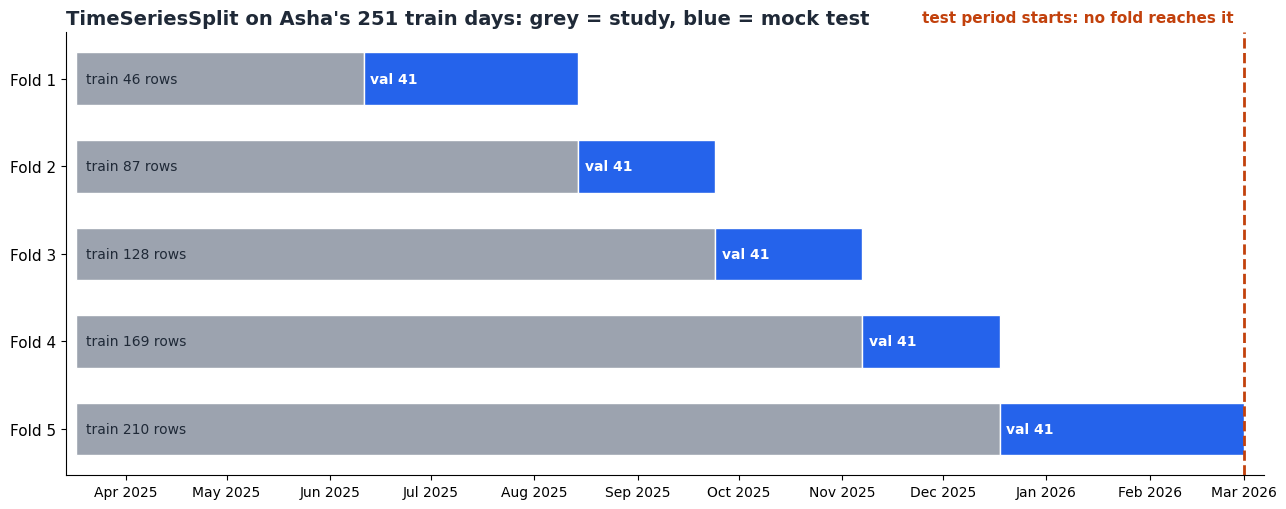

In [2]:
# Continues from Step 1: train, CUT_DATE.
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, TimeSeriesSplit

import recap_style as rs                              # the same grey + blue palette as the other DAF figures

# --- 1. Cut the 251 rows into 5 mock tests ------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)                   # 5 mock tests = 6 pieces of rows
splits = list(tscv.split(train))                     # [(train_positions, valid_positions), ...] we reuse this later

# --- 2. For every fold: look at it, and prove it is honest ---------------------------------
rows = []
for fold_number, (train_pos, valid_pos) in enumerate(splits, start=1):
    train_dates = train.index[train_pos]             # the dates of the study rows
    valid_dates = train.index[valid_pos]             # the dates of the mock-test rows

    assert train_dates.max() < valid_dates.min(), f"fold {fold_number}: validation starts before training ends"
    assert valid_dates.max() < CUT_DATE, f"fold {fold_number}: reaches the test period"
    assert not set(train_pos) & set(valid_pos), f"fold {fold_number}: a row is in both sets"

    rows.append({
        "fold": fold_number,
        "train_rows": len(train_pos),
        "valid_rows": len(valid_pos),
        "valid_from": valid_dates.min().date(),
        "valid_to": valid_dates.max().date(),
        "poor_days_in_valid": int((train["target"].iloc[valid_pos] >= 91).sum()),
    })
folds = pd.DataFrame(rows).set_index("fold")
display(folds)
print("All 5 folds: validation is after training, and nothing touches", CUT_DATE.date(), "or later.")

# --- 3. The cheating way fails the same check ---------------------------------------------
bad_folds = 0
for train_pos, valid_pos in KFold(n_splits=5, shuffle=True, random_state=0).split(train):
    if train.index[train_pos].max() > train.index[valid_pos].min():   # study days that come AFTER a test day
        bad_folds += 1
print(f"Shuffled KFold: {bad_folds} of 5 folds study on days that come after a test day.")

# --- 4. Draw the five folds on a real timeline ---------------------------------------------
fig, ax = plt.subplots(figsize=(13, 5.2))
for fold_number, (train_pos, valid_pos) in enumerate(splits, start=1):
    y = 5 - fold_number                                              # fold 1 on top
    for positions, colour in ((train_pos, rs.BAR), (valid_pos, rs.ACCENT)):
        start = train.index[positions.min()]
        width = (train.index[positions.max()] - start).days + 1
        ax.barh(y, width, left=mdates.date2num(start), height=0.6, color=colour, edgecolor="white")
    ax.text(mdates.date2num(train.index[train_pos.min()]) + 3, y, f"train {len(train_pos)} rows", va="center", fontsize=10, color=rs.INK)
    ax.text(mdates.date2num(train.index[valid_pos.min()]) + 2, y, f"val {len(valid_pos)}", va="center", fontsize=10, color="white", fontweight="bold")
ax.axvline(mdates.date2num(CUT_DATE), color=rs.ALERT, ls="--", lw=2)
ax.text(mdates.date2num(CUT_DATE) - 3, 4.65, "test period starts: no fold reaches it", ha="right", fontsize=11, color=rs.ALERT, fontweight="bold")
ax.set_yticks([4, 3, 2, 1, 0]); ax.set_yticklabels([f"Fold {k}" for k in range(1, 6)], fontsize=11)   # fold 1 on top
ax.xaxis_date(); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y")); ax.tick_params(axis="x", labelsize=10)
ax.set_xlim(mdates.date2num(train.index.min()) - 3, mdates.date2num(CUT_DATE) + 6)
ax.set_title("TimeSeriesSplit on Asha's 251 train days: grey = study, blue = mock test", loc="left", fontsize=14, fontweight="bold", color=rs.INK)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

### What this code does, line by line

**Part 0 — imports**

| Line | What it does |
|---|---|
| `import matplotlib.dates as mdates` | Tools to put real dates on a chart axis. Matplotlib stores a date as a plain number of days, and `mdates` converts back and forth |
| `import matplotlib.pyplot as plt` | `plt` is the drawing board |
| `from sklearn.model_selection import KFold, TimeSeriesSplit` | `TimeSeriesSplit` is the honest cutter. `KFold` is the shuffled cheat, which we bring only to show it fails |
| `import recap_style as rs` | Our small file `recap_style.py` with the colours of all DAF figures: grey `rs.BAR`, blue `rs.ACCENT`, red `rs.ALERT` for problems |

**Part 1 — cut the mock tests**

| Line | What it does |
|---|---|
| `tscv = TimeSeriesSplit(n_splits=5)` | Create the cutter. `n_splits=5` means five mock tests, so six pieces of rows |
| `splits = list(tscv.split(train))` | `.split(train)` gives the five folds one at a time. `list(...)` collects them. Each fold is a pair: row **positions** (0, 1, 2 …) of the study rows, and of the test rows. Positions, not dates. We keep `splits` for Step 3 onwards |

**Part 2 — look at each fold and prove it is honest**

| Line | What it does |
|---|---|
| `for fold_number, (train_pos, valid_pos) in enumerate(splits, start=1):` | Go through the five folds. `enumerate(..., start=1)` counts them 1 to 5 (not 0 to 4). The pair is unpacked into `train_pos` (study positions) and `valid_pos` (mock-test positions) |
| `train_dates = train.index[train_pos]` | Turn positions into dates: "which days are in the study pile?" |
| `valid_dates = train.index[valid_pos]` | The same for the mock-test days |
| `assert train_dates.max() < valid_dates.min(), f"..."` | **The honest check.** The last study day must be before the first test day. If not, stop with the message |
| `assert valid_dates.max() < CUT_DATE, f"..."` | **The board-paper check.** No mock-test day may reach 1 March 2026. This is acceptance criterion 2, shown in code |
| `assert not set(train_pos) & set(valid_pos), f"..."` | A `set` has no duplicates. `&` keeps what is in both. If any row is in both study and test, the set is not empty and the assert fails |
| `rows.append({...})` | Make one summary row per fold |
| `"poor_days_in_valid": int((train["target"].iloc[valid_pos] >= 91).sum())` | Take the target of the test rows (`.iloc` picks by position), mark days at 91 or more, count them |
| `folds = pd.DataFrame(rows).set_index("fold")` | Turn the list of summary rows into a table, with the fold number as the row label |
| `display(folds)` | Show the table |

**Part 3 — the cheating way fails**

| Line | What it does |
|---|---|
| `KFold(n_splits=5, shuffle=True, random_state=0).split(train)` | The shuffled cutter. `random_state=0` fixes the shuffle, so the result is the same every run |
| `if train.index[train_pos].max() > train.index[valid_pos].min():` | The same question, turned around: does the study pile contain a day **after** the first test day? |
| `bad_folds += 1` | Count the folds where it does |

**Part 4 — draw the folds**

| Line | What it does |
|---|---|
| `fig, ax = plt.subplots(figsize=(13, 5.2))` | Make a blank chart, 13 by 5.2 inches. `fig` is the page, `ax` is the chart on it |
| `y = 5 - fold_number` | The height of this fold's bar. Fold 1 gets 4, so it is on top |
| `for positions, colour in ((train_pos, rs.BAR), (valid_pos, rs.ACCENT)):` | Draw two bars per fold: the study part in grey, then the test part in blue |
| `start = train.index[positions.min()]` | The first date of this bar |
| `width = (train.index[positions.max()] - start).days + 1` | The length of the bar in days. `+ 1` counts the last day too |
| `ax.barh(y, width, left=mdates.date2num(start), ...)` | Draw a horizontal bar that starts at the date and is `width` days long |
| `ax.text(...)` (two lines) | Write "train 46 rows" in the grey bar and "val 41" in the blue bar |
| `ax.axvline(mdates.date2num(CUT_DATE), color=rs.ALERT, ls="--", lw=2)` | The red dashed line at 1 March 2026. `axvline` draws a vertical line. The test period starts here |
| `ax.set_yticks([...]); ax.set_yticklabels([...])` | Label the five bars "Fold 1" to "Fold 5" |
| `ax.xaxis_date()` and `DateFormatter("%b %Y")` | Show the horizontal axis as months, like "Oct 2025" |
| `ax.set_xlim(...)` | Start the chart a little before the first day and end it just after the cut date |
| `for side in ("top", "right"): ax.spines[side].set_visible(False)` | Remove the top and right frame lines, so the chart looks clean |
| `plt.tight_layout(); plt.show()` | Fit everything inside the page and show it |

### Read the result

| Fold | Study rows | Test rows | Test dates | Poor days in test |
|---:|---:|---:|---|---:|
| 1 | 46 | 41 | 11 Jun – 13 Aug 2025 | 3 |
| 2 | 87 | 41 | 14 Aug – 23 Sep 2025 | 0 |
| 3 | 128 | 41 | 24 Sep – 6 Nov 2025 | 23 |
| 4 | 169 | 41 | 7 Nov – 17 Dec 2025 | 41 |
| 5 | 210 | 41 | 18 Dec 2025 – 28 Feb 2026 | 39 |

**The honest cut works.** All the asserts passed: every test block comes after its study block, and the last fold ends on 28 Feb 2026, the day before the board paper. Shuffled `KFold` failed the same check in **5 of 5** folds. That answers explain-back question 1: with shuffling, the model always studies days that come after the day it is tested on.

Three things Sharma sir would point out:

- **The five mock tests are not equally hard.** Fold 2 (Aug – Sep, monsoon) has no Poor day. Fold 4 (Nov – Dec) has **only** Poor days. So one fold's score means little. We always take the **average of the five**.
- **Folds 3 and 4 are harsh.** They test on the smog season, but the study pile has hardly seen one: fold 4 studied 17 Mar – 6 Nov, and only the last few weeks of that (late Oct to early Nov, 23 Poor days) are smog. So the CV scores will look **worse** than the final test score. That is fine. We use CV only to compare **settings with each other**, never as a promise of the final number.
- **A block of 41 rows is not 41 days.** Some days are missing, so the blocks cover 41 to 73 calendar days. In fold 5 the 41 rows run from 18 Dec to 28 Feb.

**Acceptance criteria:** ✅ the fold plot shows every validation fold after its training fold. ✅ No test row is used so far, shown in code (the asserts).

## Before Step 3

Step 2 gave us `splits`: five (study, test) pairs of row positions, all honest. Step 3 puts the three models on these mock tests with their **default** settings: Ridge, RandomForest and HistGradientBoosting. Their average mock-test MAE is the "before tuning" score. It is also how we choose which tree model deserves tuning, as promised in Step 1.

# Step 3 — The "before" marks: default settings on the five mock tests

## 🎬 How we got here

**Where Asha madam stands after two steps:**

| Step | What she did | What she has now |
|---|---|---|
| 1 | Cut at 1 March 2026 and locked the 130 test days away (the board paper) | `train`: 251 days, 17 Mar 2025 to 28 Feb 2026, four features and the target |
| 2 | Cut the 251 days into five mock tests, always study first, test after | `splits`: five honest folds of 41 test days each. Shuffled `KFold` would have cheated in 5 of 5 |

She is happy. The almirah is locked, the mock tests are ready. She turns to Sharma sir and says, full of energy:

> *"Sir, now I will start turning the knobs! `alpha`, `max_depth`, `learning_rate`, I will try them all on the mock tests."*

Sharma sir raises his hand, like in the classroom. *"Ruko, ruko, beta. Wait. Before you touch a single knob, I have three questions."*

**Question 1: "What marks do you get right now?"**

> *"You have not changed anything yet. Your model has default settings. What is its average mark on the five mock tests? Write it down. Tomorrow you will come and say 'sir, it improved'. Improved from what? If you have no 'before' mark, your 'after' mark means nothing."*

**Question 2: "Compared with whom?"**

> *"A mark alone is not enough. 36 out of what? Take the laziest student in the class, the one who writes yesterday's answer again today. If your clever model cannot beat the lazy student, why are you spending a week on it?"*

This lazy student is **persistence**: "tomorrow's PM2.5 = today's PM2.5 so far". We met it in DAF-06. It costs nothing, and it is always the first person to beat.

**Question 3: "You have two tree students. Which one will you coach?"**

> *"In Step 1 you kept two tree models, the forest and the boosting. You cannot coach both with only 251 rows and one week. But do not choose by your feeling, and do not choose by looking at the board paper. Decide the rule **today**, before you see the marks. The one with the better average mock mark gets the coaching. The other one goes home."*

Asha madam writes the rule in her notebook before running anything. That is the same idea as freezing the settings before DAF-18: **a rule written after seeing the marks is not a rule, it is a justification.**

So this step is not about improving anything yet. It is about writing the **"before" marks**, and about picking who deserves the coaching.

## 😖 The problem

There are three students (models) with default settings, and we need two things from the mock tests:

1. **The "before" score of each**, to compare with the "after tuning" score in Step 6.
2. **Which tree model to tune.** In Step 1 we left RandomForest and HistGradientBoosting both in. We cannot tune both trees: that doubles the work for a small train table of 251 rows.

## 💡 The fix: same mock tests, same rule, written before looking

Every model takes the same five mock tests (`splits` from Step 2). For each we record the MAE (average error in µg/m³; lower is better) on each fold, and then the **average of the five**.

```text
model ──► fold 1 MAE ┐
          fold 2 MAE │
          fold 3 MAE ├──► average = the CV MAE   ← this is the "before" mark
          fold 4 MAE │
          fold 5 MAE ┘
```

**The rule for the tree model, written now, before we see a number:**

> The tree model with the **lower average CV MAE** goes forward to be tuned. The other one is dropped.

We also add **persistence** ("tomorrow = today so far") as a reference, the way DAF-06 did. A model that cannot beat persistence on the mock tests is not worth tuning.

## What we do in this step

1. Make the three models with **default** settings. Ridge gets a scaler inside a `Pipeline`, so the scaler is fitted inside each fold on the study rows only.
2. Score each on the five folds with `cross_val_score`, and persistence by hand.
3. Show a table of MAE per fold, with the average, and draw it.
4. Apply the rule and name the tree model.

**What "done" looks like:** a table `default_cv` (five fold scores per model), a number for each model's CV MAE, and the name of the tree model that goes to Step 5.

,ridge,random_forest,hist_gradient_boosting,persistence
fold 1,31.90,61.36,35.17,17.09
fold 2,14.66,17.71,18.33,11.24
fold 3,46.35,71.31,69.59,55.11
fold 4,52.36,89.16,56.32,57.61
fold 5,37.02,67.97,59.49,48.40
average,36.46,61.50,47.78,37.89
std (spread),14.55,26.55,20.69,22.02


Tree model that goes forward to be tuned: hist_gradient_boosting


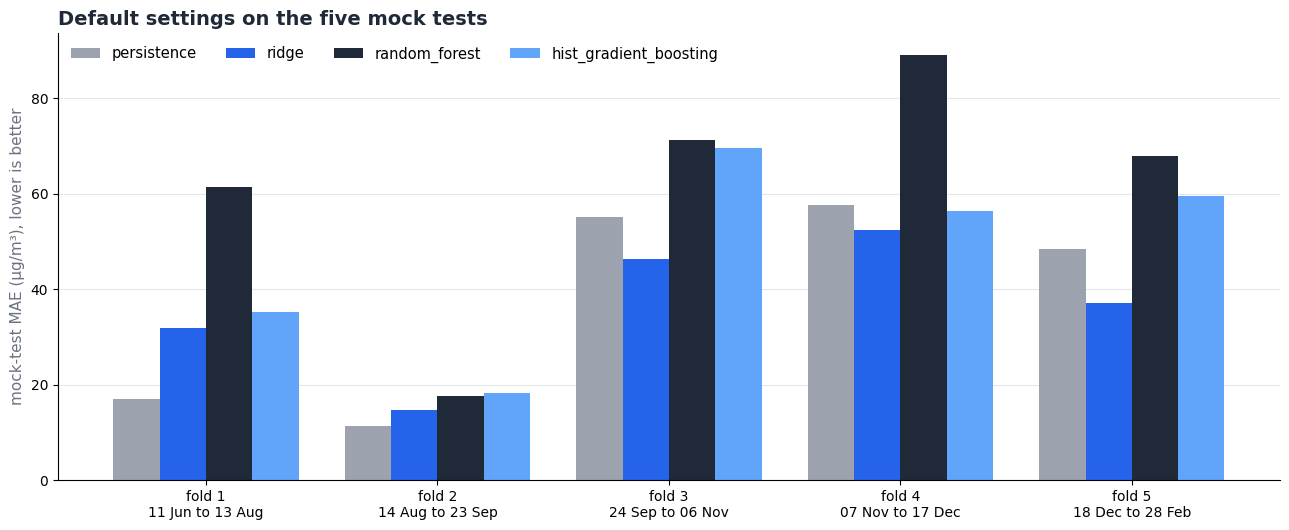

In [3]:
# Continues from Steps 1 and 2: train, feature_names, splits.
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import recap_style as rs

# --- 1. The inputs and the three students, all with DEFAULT settings -----------------------
X = train[feature_names]                              # the four features
y = train["target"]                                   # tomorrow's PM2.5, the number to predict
default_models = {
    "ridge": Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=1.0, solver="lsqr"))]),   # same as DAF-16
    "random_forest": RandomForestRegressor(random_state=0),
    "hist_gradient_boosting": HistGradientBoostingRegressor(random_state=0),
}

# --- 2. Five mock tests for each student ---------------------------------------------------
default_cv = {}
for name, model in default_models.items():
    scores = cross_val_score(model, X, y, cv=splits, scoring="neg_mean_absolute_error")   # 5 numbers, negative
    default_cv[name] = -scores                         # flip the sign: now they are plain MAE

# --- 3. Persistence as the reference: "tomorrow = today so far" -----------------------------
default_cv["persistence"] = np.array(
    [mean_absolute_error(y.iloc[valid_pos], X["pm25_until_17"].iloc[valid_pos]) for _, valid_pos in splits]
)

# --- 4. One table: a row per fold, a column per student, and the average at the bottom -------
default_table = pd.DataFrame(default_cv, index=[f"fold {k}" for k in range(1, 6)])
default_table.loc["average"] = default_table.mean()
default_table.loc["std (spread)"] = default_table.iloc[:5].std()
display(default_table.round(2))

# --- 5. The rule written before the run: lower average CV MAE wins the tree place ----------
tree_candidates = ["random_forest", "hist_gradient_boosting"]
tree_name = default_table.loc["average", tree_candidates].idxmin()
print("Tree model that goes forward to be tuned:", tree_name)

# --- 6. Draw it: one group of bars per fold ------------------------------------------------
colours = {"persistence": rs.BAR, "ridge": rs.ACCENT, "random_forest": rs.INK, "hist_gradient_boosting": "#60a5fa"}
fig, ax = plt.subplots(figsize=(13, 5.4))
x_pos = np.arange(5)
bar_width = 0.2
for j, name in enumerate(colours):
    ax.bar(x_pos + (j - 1.5) * bar_width, default_table.loc[[f"fold {k}" for k in range(1, 6)], name],
           bar_width, color=colours[name], label=name)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"fold {k}\n{row.valid_from:%d %b} to {row.valid_to:%d %b}" for k, row in folds.iterrows()], fontsize=10)
ax.set_ylabel("mock-test MAE (µg/m³), lower is better", fontsize=11, color=rs.MUTED)
ax.set_title("Default settings on the five mock tests", loc="left", fontsize=14, fontweight="bold", color=rs.INK)
ax.grid(axis="y", color=rs.GRID); ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=10.5, ncol=4, loc="upper left")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

### What this code does, line by line

**Part 0 — imports**

| Line | What it does |
|---|---|
| `from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor` | The two tree-based students. A random forest is many trees voting. Gradient boosting is trees built one after another, each fixing the mistakes of the one before |
| `from sklearn.linear_model import Ridge` | The straight-line student. Ridge is a normal line fit, but it keeps the weights small, so it does not over-react to noise |
| `from sklearn.metrics import mean_absolute_error` | MAE: the average of `|real - forecast|` |
| `from sklearn.model_selection import cross_val_score` | Runs the whole mock-test loop for one model: fit on the study rows, score on the test rows, five times |
| `from sklearn.pipeline import Pipeline` | A chain of steps that behaves like one model |
| `from sklearn.preprocessing import StandardScaler` | Rescales every feature to a similar size (mean 0, spread 1). Ridge needs it. Trees do not |

**Part 1 — inputs and the three students**

| Line | What it does |
|---|---|
| `X = train[feature_names]` | `X` is the table of inputs: the four features |
| `y = train["target"]` | `y` is the answer column: tomorrow's PM2.5 |
| `"ridge": Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=1.0, solver="lsqr"))])` | Ridge **with its scaler tied to it**. Inside every fold, the scaler learns its mean and spread from the study rows only and then applies them to the test rows. That is the leakage rule from CLAUDE.md. `alpha=1.0` and `solver="lsqr"` are the same as in DAF-16 |
| `RandomForestRegressor(random_state=0)` | All default settings. `random_state=0` fixes the randomness, so a re-run gives the same numbers |
| `HistGradientBoostingRegressor(random_state=0)` | The same, default settings |

**Part 2 — five mock tests for each student**

| Line | What it does |
|---|---|
| `for name, model in default_models.items():` | Take the three students one by one |
| `cross_val_score(model, X, y, cv=splits, scoring="neg_mean_absolute_error")` | For each of our five folds: fit a fresh copy of the model on the study rows, predict the test rows, score. `cv=splits` is **our** honest folds from Step 2. It returns 5 numbers. They are **negative** because sklearn always treats "higher is better", so an error is stored as minus |
| `default_cv[name] = -scores` | Put the minus back to plus, so we read plain MAE |

**Part 3 — persistence, the reference**

| Line | What it does |
|---|---|
| `[mean_absolute_error(y.iloc[valid_pos], X["pm25_until_17"].iloc[valid_pos]) for _, valid_pos in splits]` | No model here. Forecast "tomorrow" as the `pm25_until_17` column and score it on each fold's test rows. The `_` ignores the study positions, which persistence does not need. `.iloc[...]` picks rows by position |
| `np.array([...])` | Put the five numbers in an array like the others |

**Part 4 — the table**

| Line | What it does |
|---|---|
| `pd.DataFrame(default_cv, index=[f"fold {k}" ...])` | One column per student, one row per fold |
| `default_table.loc["average"] = default_table.mean()` | Add a row with the average of each column. This is the **CV MAE**, the "before" mark |
| `default_table.loc["std (spread)"] = default_table.iloc[:5].std()` | Add the spread of the five fold scores. `.iloc[:5]` takes only the first five rows, so the average row is not counted. A big spread means the model's marks jump around from test to test |
| `display(default_table.round(2))` | Show it with two decimals |

**Part 5 — the rule**

| Line | What it does |
|---|---|
| `tree_candidates = [...]` | The two names that compete for the tree place |
| `default_table.loc["average", tree_candidates].idxmin()` | Look at the two averages, return the **name** of the smaller. `idxmin` means "index of the minimum" |

**Part 6 — the picture**

| Line | What it does |
|---|---|
| `colours = {...}` | One colour per student. Grey for the reference, blue for Ridge, the other two for the trees |
| `x_pos = np.arange(5)` | The five horizontal positions, one per fold |
| `ax.bar(x_pos + (j - 1.5) * bar_width, ..., bar_width, ...)` | Draw four bars per fold side by side. `(j - 1.5) * bar_width` shifts each student a little left or right of the fold's centre |
| `default_table.loc[[f"fold {k}" ...], name]` | Take only the five fold rows for this student (not the average rows) |
| `ax.set_xticklabels([... for k, row in folds.iterrows()])` | Label every fold with its dates, taken from the `folds` table of Step 2 |
| `ax.legend(..., ncol=4)` | The colour key in one row |

### Read the result

| Mock-test MAE, default settings | Average of 5 folds | Spread |
|---|---:|---:|
| **Ridge** | **36.46** | 14.55 |
| Persistence ("tomorrow = today so far") | 37.89 | 22.02 |
| HistGradientBoosting | 47.78 | 20.69 |
| RandomForest | 61.50 | 26.55 |

**The tree place goes to HistGradientBoosting** (47.78 against 61.50). The rule was written before the run, and it did not change.

Four things Sharma sir would say about this table:

- **Ridge is the best "before" mark, but only just.** It beats persistence by 1.4 µg/m³ on average. Persistence is a hard reference here. That is the DAF-06 lesson again.
- **Both trees lose to persistence.** On the mock tests, a forest or boosting with default settings is worse than copying today. It looks strange, but on this small table (46 to 210 rows) the reason is clear: **a tree can only repeat what it has seen during study.** In fold 1, the forest studied a spring-heavy pile and forecast 103 on average, but the real monsoon average was 51. In fold 3, it had never seen a smog season: it forecast 68 on average where the real average was 131. A line (Ridge) can follow the rising days. A tree cannot.
- **Fold 4 is the hardest** for the forest (89) and **fold 2 the easiest** for everybody (11 to 18). Same as in Step 2: the folds are not equally hard.
- **Is tuning worth it for the trees?** We will see in Step 5 and Step 6. Do not expect a tree to beat Ridge. A fair target is to close part of the gap to persistence and Ridge. If it does not, we say so, and Ridge is the final model.

These are the **"before" marks**. They are saved in `default_table` and `default_cv`, and Step 6 will compare tuned scores with them. Nothing was fitted on the locked days.

**Acceptance criteria:** ⏳ tuned vs default CV MAE for both models: the default half is done.

## Before Step 4

Step 3 gave us the "before" marks (Ridge 36.46, HistGradientBoosting 47.78) and chose **HistGradientBoosting** as the tree model. Step 4 tunes Ridge, the easy one: one setting, `alpha`. We will use `RandomizedSearchCV` on our five honest folds, and Sharma sir's mock tests will tell us if a different `alpha` is worth the effort.

# Step 4 — Coach the first student: tuning Ridge's one knob

## 🎬 How we got here

Step 3 wrote the "before" marks on the board:

| Student | Average mock-test MAE (default settings) |
|---|---:|
| Ridge | 36.46 |
| Persistence (the lazy student) | 37.89 |
| HistGradientBoosting | 47.78 |
| RandomForest | 61.50 |

The tree place went to HistGradientBoosting. Now Asha madam finally gets to turn the knobs. Sharma sir says:

> *"Start with the easy student. Ridge has just **one** knob. Try it properly, on the mock tests only. And beta, tell me honestly at the end: did it help, or did it not?"*

## 😖 The problem

Ridge's one knob is **`alpha`**. Sharma sir's way to understand it: alpha is **how strict the tutor is**.

```text
alpha very small (0.01)             alpha very large (1000)
tutor says: "draw any line          tutor says: "keep every weight tiny,
 you like, follow the data"          do not trust any feature too much"
→ a free line                       → a stiff, almost flat line
→ can follow the smog days          → ignores the features and forecasts
                                      "about the average" every day
```

Too free and the line may chase noise. Too stiff and it cannot follow the smog at all. The right alpha is somewhere in between, but nobody knows where. Default is `alpha=1.0`, which is just a round number someone picked. We must try other values.

Two questions come up:

1. **Which alphas do we try?** Alpha matters in *multiples*: the difference between 0.01 and 0.1 matters, but between 5.00 and 5.01 does not. So we do not try 1, 2, 3, 4 …. We try values spread evenly on a **log scale**: 0.01, 0.1, 1, 10, 100, 1000, and everything in between, like checking one rupee, ten rupees, hundred rupees, thousand rupees.
2. **How do we score each alpha?** On the same five honest mock tests (`splits`), the same way as in Step 3. The test days stay in the almirah.

## 💡 The fix: RandomizedSearchCV

`RandomizedSearchCV` is a machine that does the whole job:

```text
pick a random alpha  ──►  fit Ridge on fold 1's study rows, score on its test rows
                          fit on fold 2 ... fold 3 ... fold 4 ... fold 5
                     ──►  average of five = the mark of this alpha
repeat for 20 alphas ──►  sort by mark, best on top
```

20 alphas × 5 folds = **100 mock tests**. For one knob, a plain list of values would also work. We use `RandomizedSearchCV` here because in Step 5 the tree model has **four** knobs, and then the random search really earns its place. Same tool, same pattern.

## What we do in this step

1. Make the Ridge pipeline (scaler + Ridge) with `alpha` left open.
2. Run the search: 20 random alphas on our five folds.
3. Show the best alphas, and compare **tuned vs default** on the same five folds.
4. Draw all 20 tries.

**What "done" looks like:** the best alpha, its CV MAE next to the default 36.456, how many folds improved, and a picture of the knob. We also keep the five fold scores of the winner, `tuned_ridge_folds`, for the comparison in Step 6.

,alpha,cv_mae
0,0.013,36.409
1,0.023,36.410
2,0.027,36.410
3,0.826,36.448
4,1.313,36.472


default alpha = 1.0      -> CV MAE 36.456
tuned   alpha = 0.013    -> CV MAE 36.409
gain: 0.047 µg/m³  (0.1%)
folds improved: 3 of 5


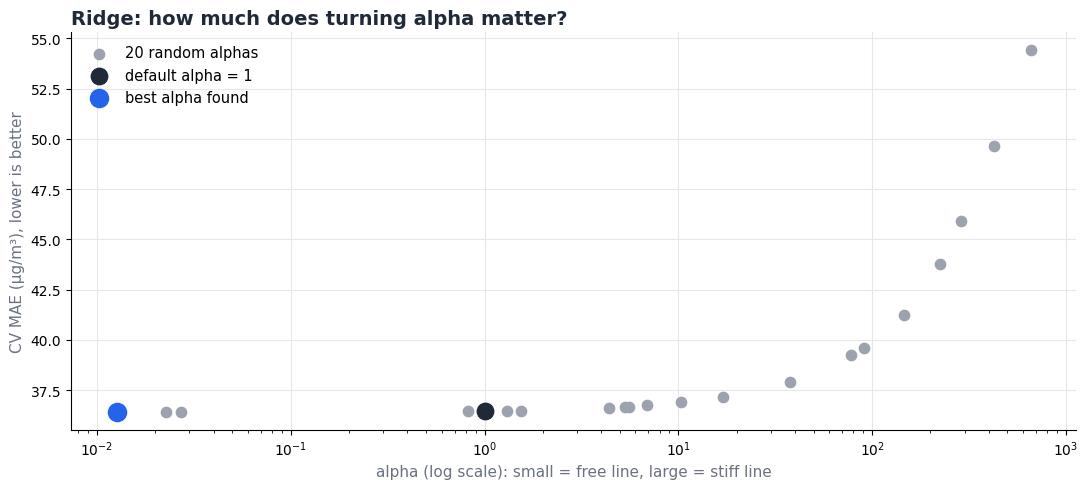

In [4]:
# Continues from Steps 1 to 3: train, feature_names, splits, X, y, default_cv, default_table.
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV

# --- 1. The student, and the one knob we are allowed to turn -------------------------------
ridge_pipe = Pipeline([("scale", StandardScaler()), ("model", Ridge(solver="lsqr"))])   # alpha is left open
alpha_choices = {"model__alpha": loguniform(1e-2, 1e3)}      # any value from 0.01 to 1000, spread evenly on a log scale

# --- 2. The search: 20 random alphas x our 5 honest folds = 100 mock tests ------------------
ridge_search = RandomizedSearchCV(
    ridge_pipe,
    param_distributions=alpha_choices,
    n_iter=20,                                       # try 20 random alphas
    cv=splits,                                       # the honest folds from Step 2, nothing else
    scoring="neg_mean_absolute_error",
    random_state=0,                                  # same 20 alphas on every run
    refit=False,                                     # no final model yet: that is DAF-18's job
)
ridge_search.fit(X, y)                               # only train rows go in

# --- 3. Read the results: one row per alpha, best first -------------------------------------
results = pd.DataFrame(ridge_search.cv_results_)
ridge_results = pd.DataFrame({
    "alpha": results["param_model__alpha"].astype(float),
    "cv_mae": -results["mean_test_score"],           # average of the 5 folds, back to plain MAE
}).sort_values("cv_mae").reset_index(drop=True)
display(ridge_results.head(5).round(3))

# --- 4. Tuned vs default, on the same five folds ---------------------------------------------
best_row = results.loc[ridge_search.best_index_]
tuned_ridge_folds = np.array([-best_row[f"split{k}_test_score"] for k in range(5)])    # 5 fold scores of the winner
default_ridge_folds = default_cv["ridge"]                                              # from Step 3 (alpha = 1.0)
best_alpha = ridge_search.best_params_["model__alpha"]
print(f"default alpha = 1.0      -> CV MAE {default_ridge_folds.mean():.3f}")
print(f"tuned   alpha = {best_alpha:<8.3f} -> CV MAE {tuned_ridge_folds.mean():.3f}")
print(f"gain: {default_ridge_folds.mean() - tuned_ridge_folds.mean():.3f} µg/m³  "
      f"({(default_ridge_folds.mean() - tuned_ridge_folds.mean()) / default_ridge_folds.mean():.1%})")
print("folds improved:", int((tuned_ridge_folds < default_ridge_folds).sum()), "of 5")

# --- 5. Draw all 20 tries: where is the knob good, where is it bad? --------------------------
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(ridge_results["alpha"], ridge_results["cv_mae"], s=55, color=rs.BAR, zorder=3, label="20 random alphas")
ax.scatter([1.0], [default_ridge_folds.mean()], s=140, color=rs.INK, zorder=4, label="default alpha = 1")
ax.scatter([best_alpha], [tuned_ridge_folds.mean()], s=170, color=rs.ACCENT, zorder=5, label="best alpha found")
ax.set_xscale("log")
ax.set_xlabel("alpha (log scale): small = free line, large = stiff line", fontsize=11, color=rs.MUTED)
ax.set_ylabel("CV MAE (µg/m³), lower is better", fontsize=11, color=rs.MUTED)
ax.set_title("Ridge: how much does turning alpha matter?", loc="left", fontsize=14, fontweight="bold", color=rs.INK)
ax.grid(color=rs.GRID); ax.set_axisbelow(True); ax.legend(frameon=False, fontsize=10.5)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

### Every alpha we tried, in one table

The picture shows 20 dots. Here are the same 20, **sorted by alpha** from the smallest to the largest, so the flat valley and the cliff are easy to read. Each row is one alpha, with its mark on each of the five mock tests, the average, and the difference from the default (alpha = 1.0, average 36.456). A negative difference means better than default.

In [5]:
# Continues from the search above: results, default_ridge_folds.
all_tries = pd.DataFrame({"alpha": results["param_model__alpha"].astype(float)})        # one row per tried alpha
for k in range(5):
    all_tries[f"fold {k + 1}"] = -results[f"split{k}_test_score"]                       # that alpha's mark on mock test k + 1
all_tries["average"] = -results["mean_test_score"]                                      # the CV MAE
all_tries["vs default"] = all_tries["average"] - default_ridge_folds.mean()             # below 0 = better than alpha 1.0
all_tries["rank"] = all_tries["average"].rank(method="first").astype(int)               # 1 = best of the 20

all_tries = all_tries.sort_values("alpha").reset_index(drop=True)                       # smallest alpha first
all_tries.index = all_tries.index + 1                                                   # number the rows 1 to 20
display(all_tries.round(3))
print("alphas tried:", len(all_tries), "| better than default:", int((all_tries["vs default"] < 0).sum()),
      "| worse than default:", int((all_tries["vs default"] > 0).sum()))

,alpha,fold 1,fold 2,fold 3,fold 4,fold 5,average,vs default,rank
1,0.013,31.754,14.585,46.384,52.256,37.066,36.409,-0.047,1
2,0.023,31.756,14.586,46.384,52.257,37.066,36.410,-0.047,2
3,0.027,31.757,14.586,46.384,52.258,37.066,36.410,-0.047,3
4,0.826,31.873,14.645,46.358,52.338,37.025,36.448,-0.008,4
5,1.313,31.941,14.680,46.345,52.388,37.004,36.472,0.015,5
6,1.541,31.973,14.696,46.340,52.412,36.995,36.483,0.027,6
7,4.410,32.349,14.881,46.301,52.701,36.902,36.627,0.171,7
8,5.302,32.452,14.934,46.296,52.789,36.879,36.670,0.214,8
9,5.547,32.480,14.949,46.296,52.812,36.873,36.682,0.226,9
10,6.922,32.626,15.027,46.295,52.944,36.842,36.747,0.290,10


alphas tried: 20 | better than default: 4 | worse than default: 16


**What this code does, line by line**

| Line | What it does |
|---|---|
| `pd.DataFrame({"alpha": results["param_model__alpha"].astype(float)})` | Start a new table with one column: the 20 alphas the search drew, as plain numbers |
| `for k in range(5):` | Go through the five mock tests (`k` is 0, 1, 2, 3, 4) |
| `all_tries[f"fold {k + 1}"] = -results[f"split{k}_test_score"]` | Add a column named "fold 1" … "fold 5". The search stored each alpha's score on each fold as `split0_test_score` … `split4_test_score`. The minus flips sklearn's negative score back to a plain MAE |
| `all_tries["average"] = -results["mean_test_score"]` | The average of the five folds, the same CV MAE as before |
| `all_tries["vs default"] = all_tries["average"] - default_ridge_folds.mean()` | How far this alpha is from the default's 36.456. Negative means better than default, positive means worse |
| `.rank(method="first").astype(int)` | Give each alpha a place: 1 for the lowest MAE. `method="first"` breaks ties by order, so the places are always 1 to 20 |
| `.sort_values("alpha").reset_index(drop=True)` | Order the rows by alpha, smallest first, and renumber them |
| `all_tries.index = all_tries.index + 1` | `reset_index` starts at 0. Add 1, so the rows are numbered 1 to 20 like a normal list |
| `display(all_tries.round(3))` | Show the table with 3 decimals |
| `int((all_tries["vs default"] < 0).sum())` | Count the alphas that beat the default (`< 0` is True or False per row, and `.sum()` counts the True) |

### What this code does, line by line

**Part 1 — the student and the knob**

| Line | What it does |
|---|---|
| `from scipy.stats import loguniform` | A "random number machine" that draws numbers evenly on a log scale. `scipy` is the maths library under scikit-learn |
| `from sklearn.model_selection import RandomizedSearchCV` | The coaching machine described above |
| `ridge_pipe = Pipeline([("scale", StandardScaler()), ("model", Ridge(solver="lsqr"))])` | The same Ridge as in Step 3 (scaler first, Ridge second), but this time we **do not give alpha**. It stays open for the search to fill. `solver="lsqr"` is fixed, as in DAF-16, so alpha is the only thing that changes |
| `alpha_choices = {"model__alpha": loguniform(1e-2, 1e3)}` | The menu of the search. The key `"model__alpha"` means "the `alpha` of the step named `model`" (two underscores: step name, then setting name). `loguniform(1e-2, 1e3)` means: any number from 0.01 to 1000, spread evenly on a log scale. `1e-2` is Python for 0.01 |

**Part 2 — the search**

| Line | What it does |
|---|---|
| `RandomizedSearchCV(ridge_pipe, param_distributions=alpha_choices, ...)` | Build the machine: "take this pipeline, and draw its settings from this menu" |
| `n_iter=20` | Try 20 random alphas. More tries cost more time and, on only 251 rows, can start to overfit the mock tests themselves |
| `cv=splits` | Use **our** five honest folds. Without this, sklearn would make its own folds, and for a regression it would use a plain `KFold`, which does not respect time |
| `scoring="neg_mean_absolute_error"` | Judge by MAE. Negative, because sklearn always picks the **highest** score |
| `random_state=0` | The same 20 random alphas every time we run |
| `refit=False` | Normally the search finishes by training the best model on all rows. We do not want a final model now. Fitting the final model is DAF-18's work. So we switch it off |
| `ridge_search.fit(X, y)` | Run it: 100 mock tests. Only the train table `X`, `y` is passed in, so no test row can be involved |

**Part 3 — read the results**

| Line | What it does |
|---|---|
| `results = pd.DataFrame(ridge_search.cv_results_)` | `cv_results_` is the full record of the search: every alpha, every fold score. We turn it into a table |
| `results["param_model__alpha"].astype(float)` | The alpha column of the record. `astype(float)` makes it a normal number |
| `-results["mean_test_score"]` | The average of the five folds, with the minus flipped back, so it reads as MAE |
| `.sort_values("cv_mae").reset_index(drop=True)` | Best alpha (lowest MAE) on top, and renumber the rows 0, 1, 2 … |
| `display(ridge_results.head(5).round(3))` | Show the five best |

**Part 4 — tuned vs default**

| Line | What it does |
|---|---|
| `best_row = results.loc[ridge_search.best_index_]` | The row of the winning alpha. `best_index_` is the machine's own note of which try was best |
| `np.array([-best_row[f"split{k}_test_score"] for k in range(5)])` | The record also keeps each fold's score as `split0_test_score` … `split4_test_score`. We collect the five of the winner, as plain MAE |
| `default_ridge_folds = default_cv["ridge"]` | The default alpha=1.0 fold scores, from Step 3 |
| `best_alpha = ridge_search.best_params_["model__alpha"]` | The value of the winning alpha |
| `print(f"...{best_alpha:<8.3f}...")` | `:<8.3f` means "three decimals, left-aligned in 8 spaces", so the lines line up |
| `(tuned_ridge_folds < default_ridge_folds).sum()` | Compare fold by fold. `<` gives True/False for each of the five folds, and `.sum()` counts the True: the folds where tuning won |

**Part 5 — the picture**

| Line | What it does |
|---|---|
| `ax.scatter(ridge_results["alpha"], ridge_results["cv_mae"], ...)` | One grey dot per tried alpha: alpha across, error up |
| `ax.scatter([1.0], [default_ridge_folds.mean()], ...)` | The default (alpha=1) as a big dark dot, so we can see the starting point |
| `ax.scatter([best_alpha], [tuned_ridge_folds.mean()], ...)` | The winner as a big blue dot |
| `ax.set_xscale("log")` | Put alpha on a log axis, the same way we drew the tries |

### Read the result

| | alpha | CV MAE (average of 5 folds) |
|---|---:|---:|
| Default (Step 3) | 1.0 | 36.456 |
| **Tuned (best of 20)** | **0.013** | **36.409** |
| Gain | | **0.047 µg/m³ (0.1%)** |

The gain is **0.047**. Tuning improved 3 of the 5 folds (1, 2 and 4) and made the other 2 very slightly worse (3 and 5). The fold-to-fold swing is about 14 µg/m³, so a gain of 0.05 is lost in the noise.

What the picture shows, in Sharma sir's words:

- **A flat valley.** Every alpha from 0.01 up to about 5 gives the same mark, between 36.41 and 36.67. The model does not care whether the tutor is strict "a little" or "very little".
- **A cliff on the right.** From alpha 40 the error climbs: 37.9 at alpha 38, 41.2 at 146, 54.4 at 658. A stiff line cannot follow the smog days, exactly as the story said.
- **The winner is just the lowest point of a flat floor.** 0.013, 0.023 and 0.027 are tied at 36.41. We would not trust "0.013 is the best alpha" as a fact. It is only "one of many alphas that are equally good".

**So did tuning help? No, not in any way that matters.** Picture 6 in the walkthrough had hinted at this. Ridge with four features has very little to tune. The default `alpha=1.0` was already in the flat valley.

Two honest warnings:

- **The winner's score is a little optimistic.** We chose the best of 20 using the same five folds that gave the score. Even a no-change knob looks slightly better when you pick the best of 20 tries. The real check is DAF-18.
- **Do not read "36.4" as the final error.** The mock tests include hard smog-season folds where Ridge studied almost no smog. The number is for comparing settings with each other.

We keep `tuned_ridge_folds` and `ridge_results` for Step 6, where we decide, for both models, whether tuning was worth the complexity. For Ridge the answer is already leaning: **keep the simple default**, unless Step 6 finds a reason not to.

**Acceptance criteria:** ⏳ tuned vs default CV MAE: Ridge is now reported (36.409 vs 36.456). The tree model comes in Step 5. ✅ No test row was used: `X` and `y` come from `train`.

## Before Step 5

Step 4 showed that Ridge's one knob hardly matters: a flat valley, with a tuned gain of 0.047. The tree model is different. HistGradientBoosting has **four** knobs (`learning_rate`, `max_depth`, `min_samples_leaf`, `max_iter`), and its default score (47.78) is far from Ridge's (36.46), so there is much more room to gain. Step 5 searches those four knobs together with the same `RandomizedSearchCV`. That is where "random search" really earns its place: four knobs with five values each is hundreds of combinations.

# Step 5 — Coach the second student: four knobs on HistGradientBoosting

## 🎬 How we got here

Step 4 coached the easy student, Ridge, with one knob. The result was honest and a little boring:

| | Default | Tuned | Gain |
|---|---:|---:|---:|
| Ridge CV MAE | 36.456 | 36.409 | 0.047 (0.1%) |

Sharma sir smiles. *"Not every coaching works, beta. Sometimes the student was already fine. Now take the second student, the boosting model. This one is far from the top of the class. Maybe here the coaching will matter."*

Asha madam looks at the Step 3 marks: HistGradientBoosting 47.78, against Ridge 36.46 and the lazy persistence 37.89. There is an **11-mark gap** to Ridge. If any student can gain from coaching, it is this one.

## 😖 The problem

Ridge had one knob. HistGradientBoosting has **four**, and they pull against each other. Sharma sir explains them as a way to study:

```text
Knob               In plain words                          Too low             Too high
learning_rate      how big a correction each new           learns very slowly  jumps around, overshoots
                   "revision round" makes                  (needs many rounds)
max_iter           how many revision rounds in total       under-prepared      memorises the notes
max_depth          how many questions in a row one         too simple          answers so specific it
                   decision tree may ask                   (2 questions)       fits single days
min_samples_leaf   the fewest days that must sit in        a rule for 5 days   rules too general
                   one answer box                          = memorising
```

Boosting is like a student who does **many short revision rounds**. In every round, he looks at the questions he got wrong, and fixes a little. `learning_rate` is how much he fixes each round. `max_iter` is how many rounds. A slow learner (small rate) needs many rounds, so the two knobs are linked.

With 4 knobs and 4 to 5 sensible values each, there are hundreds of combinations. Trying all of them on 5 folds is well over a thousand mock tests, and still a waste, because most of the combinations are close to each other. That is where **random search** earns its place: it draws combinations at random and usually lands in a good region.

## 💡 The fix: the same machine, a bigger menu

```text
menu:  learning_rate  any value 0.01 to 0.3   (log scale, as for alpha)
       max_depth      2, 3, 4, 6, no limit
       min_samples_leaf  5, 10, 20, 30, 40
       max_iter       50, 100, 200, 300

draw 30 random combinations  ──►  5 honest folds each  ──►  150 mock tests
sort by average mark, best on top
```

The rule for success is written **now**, in the same spirit as Step 3: *the tuned setting is only worth keeping if it beats the default (47.782) on the average and does not lose on most of the folds.* A gain that comes from one lucky fold is not a gain.

## What we do in this step

1. Write the menu for the four knobs, and run `RandomizedSearchCV` with 30 draws on our five folds.
2. List every one of the 30 tries, best first.
3. Compare the winner with the default **fold by fold**, and with Ridge and persistence.
4. Draw all 30 against the reference marks.

**What "done" looks like:** the best four settings, tuned vs default CV MAE, a fold-by-fold table, and `tuned_tree_folds` and `best_tree_params` saved for Steps 6 and 7.

,learning_rate,max_depth,min_samples_leaf,max_iter,cv_mae
1,0.062,2,20,300,47.683
2,0.023,2,10,100,47.875
3,0.253,2,20,100,48.052
4,0.064,3,20,300,48.418
5,0.065,2,30,300,48.460
6,0.099,2,30,100,48.637
7,0.152,6,30,100,48.821
8,0.041,6,30,200,48.969
9,0.035,2,30,200,49.207
10,0.248,3,20,200,49.236


best settings: {'learning_rate': 0.062, 'max_depth': 2, 'max_iter': 300, 'min_samples_leaf': 20}
default settings -> CV MAE 47.782
tuned settings   -> CV MAE 47.683
gain: 0.099 µg/m³ (0.2%) | folds improved: 1 of 5


,default,tuned,tuned - default
fold 1,35.17,35.84,0.67
fold 2,18.33,20.40,2.07
fold 3,69.59,70.84,1.24
fold 4,56.32,56.95,0.62
fold 5,59.49,54.40,-5.10


for comparison: tuned Ridge 36.409 | persistence 37.889


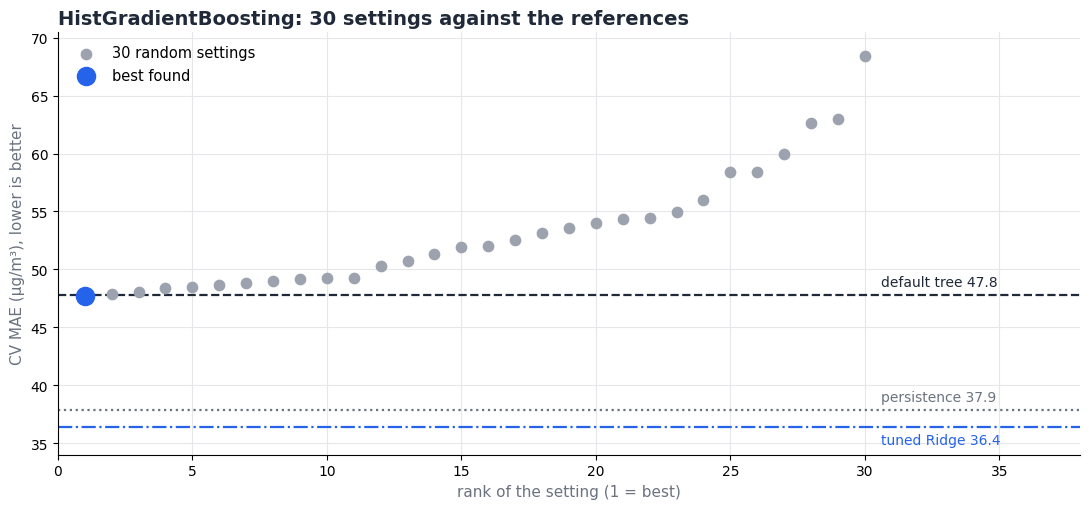

In [6]:
# Continues from Steps 1 to 4: X, y, splits, default_cv, tree_name, ridge_results, default_table.
assert tree_name == "hist_gradient_boosting"          # the place won in Step 3

# --- 1. The student, and the four knobs, each with its menu ---------------------------------
tree_choices = {
    "learning_rate":    loguniform(1e-2, 3e-1),       # how big a correction each new tree makes: 0.01 to 0.3
    "max_depth":        [2, 3, 4, 6, None],           # how many questions a tree may ask in a row (None = no limit)
    "min_samples_leaf": [5, 10, 20, 30, 40],          # the fewest days allowed in a final answer box
    "max_iter":         [50, 100, 200, 300],          # how many trees in total
}

# --- 2. The search: 30 random combinations x 5 honest folds = 150 mock tests -----------------
tree_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=0),
    param_distributions=tree_choices,
    n_iter=30,
    cv=splits,
    scoring="neg_mean_absolute_error",
    random_state=0,
    refit=False,
)
tree_search.fit(X, y)                                 # only train rows go in

# --- 3. Every try, best first --------------------------------------------------------------
tree_results = pd.DataFrame(tree_search.cv_results_)
tree_tries = pd.DataFrame({
    "learning_rate": tree_results["param_learning_rate"].astype(float),
    "max_depth": tree_results["param_max_depth"],
    "min_samples_leaf": tree_results["param_min_samples_leaf"],
    "max_iter": tree_results["param_max_iter"],
    "cv_mae": -tree_results["mean_test_score"],
}).sort_values("cv_mae").reset_index(drop=True)
tree_tries.index = tree_tries.index + 1               # rank 1 = best
display(tree_tries.round(3))

# --- 4. Tuned vs default, on the same five folds ---------------------------------------------
best_tree = tree_results.loc[tree_search.best_index_]
tuned_tree_folds = np.array([-best_tree[f"split{k}_test_score"] for k in range(5)])
default_tree_folds = default_cv[tree_name]
best_tree_params = {name: (round(float(v), 3) if name == "learning_rate" else v) for name, v in tree_search.best_params_.items()}
print("best settings:", best_tree_params)
print(f"default settings -> CV MAE {default_tree_folds.mean():.3f}")
print(f"tuned settings   -> CV MAE {tuned_tree_folds.mean():.3f}")
gain = default_tree_folds.mean() - tuned_tree_folds.mean()
print(f"gain: {gain:.3f} µg/m³ ({gain / default_tree_folds.mean():.1%}) | folds improved: "
      f"{int((tuned_tree_folds < default_tree_folds).sum())} of 5")
display(pd.DataFrame({"default": default_tree_folds, "tuned": tuned_tree_folds, "tuned - default": tuned_tree_folds - default_tree_folds},
                     index=[f"fold {k}" for k in range(1, 6)]).round(2))
print(f"for comparison: tuned Ridge {ridge_results['cv_mae'].min():.3f} | persistence {default_table.loc['average', 'persistence']:.3f}")

# --- 5. Draw all 30 tries against the three reference marks -----------------------------------
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.scatter(tree_tries.index, tree_tries["cv_mae"], s=55, color=rs.BAR, zorder=3, label="30 random settings")
ax.scatter([1], [tuned_tree_folds.mean()], s=170, color=rs.ACCENT, zorder=5, label="best found")
for value, label, colour, style in ((default_tree_folds.mean(), "default tree", rs.INK, "--"),
                                    (default_table.loc["average", "persistence"], "persistence", rs.MUTED, ":"),
                                    (ridge_results["cv_mae"].min(), "tuned Ridge", rs.ACCENT, "-.")):
    ax.axhline(value, color=colour, ls=style, lw=1.6)
    ax.text(len(tree_tries) + 0.6, value + (-0.5 if label == "tuned Ridge" else 0.5), f"{label} {value:.1f}",
            va="top" if label == "tuned Ridge" else "bottom", fontsize=10, color=colour)
ax.set_xlim(0, len(tree_tries) + 8)
ax.set_ylim(34, tree_tries["cv_mae"].max() + 2)
ax.set_xlabel("rank of the setting (1 = best)", fontsize=11, color=rs.MUTED)
ax.set_ylabel("CV MAE (µg/m³), lower is better", fontsize=11, color=rs.MUTED)
ax.set_title("HistGradientBoosting: 30 settings against the references", loc="left", fontsize=14, fontweight="bold", color=rs.INK)
ax.grid(color=rs.GRID); ax.set_axisbelow(True); ax.legend(frameon=False, fontsize=10.5, loc="upper left")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

### What this code does, line by line

**Part 0 — the guard**

| Line | What it does |
|---|---|
| `assert tree_name == "hist_gradient_boosting"` | Step 3 chose the tree model by a rule. This line stops the notebook if that choice was ever different, so Step 5 never tunes the wrong student |

**Part 1 — the menu**

| Line | What it does |
|---|---|
| `"learning_rate": loguniform(1e-2, 3e-1)` | Any value from 0.01 to 0.3, spread evenly on a log scale, like alpha. `3e-1` is Python for 0.3 |
| `"max_depth": [2, 3, 4, 6, None]` | A **list**: the search picks one of these five. `None` means "no limit on the depth", which is the default |
| `"min_samples_leaf": [5, 10, 20, 30, 40]` | The fewest days in a final answer box. The default is 20 |
| `"max_iter": [50, 100, 200, 300]` | The number of revision rounds. The default is 100 |

**Part 2 — the search**

| Line | What it does |
|---|---|
| `HistGradientBoostingRegressor(random_state=0)` | The student with default settings. The search overwrites the four knobs in each try. `random_state=0` keeps the rest of its randomness fixed |
| `param_distributions=tree_choices` | The menu above. The name says "distributions", but a plain list works too: the search picks one item at random |
| `n_iter=30` | 30 random combinations. More than for Ridge, because there are four knobs |
| `cv=splits`, `scoring=...`, `random_state=0`, `refit=False` | Same as Step 4: our honest folds, MAE as the mark, the same draws each run, and no final model yet |
| `tree_search.fit(X, y)` | Run 30 × 5 = 150 mock tests. Only train rows go in |

**Part 3 — every try, best first**

| Line | What it does |
|---|---|
| `tree_results = pd.DataFrame(tree_search.cv_results_)` | The full record of the search as a table |
| `tree_results["param_learning_rate"].astype(float)` | The value of each knob in each try. `param_<name>` is how sklearn names these columns |
| `-tree_results["mean_test_score"]` | The average of the five fold scores, minus flipped back to plain MAE |
| `.sort_values("cv_mae").reset_index(drop=True)` | Best on top, rows renumbered |
| `tree_tries.index = tree_tries.index + 1` | Number the rows from 1, so the row number is the rank |

**Part 4 — tuned vs default**

| Line | What it does |
|---|---|
| `best_tree = tree_results.loc[tree_search.best_index_]` | The record row of the best try |
| `[-best_tree[f"split{k}_test_score"] for k in range(5)]` | The best try's five fold scores, as plain MAE |
| `default_tree_folds = default_cv[tree_name]` | The default's five fold scores, from Step 3 |
| `{name: (round(float(v), 3) if name == "learning_rate" else v) ...}` | A tidy copy of the best settings. The learning rate is rounded to 3 decimals, so it prints as `0.062` and not as a long number |
| `gain = default... - tuned...` | Positive means tuning helped |
| `(tuned_tree_folds < default_tree_folds).sum()` | In how many of the 5 folds did the tuned settings beat the default? |
| `display(pd.DataFrame({...}, index=[...]))` | The fold-by-fold table: default, tuned, and the difference. Negative difference = tuned is better in that fold |

**Part 5 — the picture**

| Line | What it does |
|---|---|
| `ax.scatter(tree_tries.index, tree_tries["cv_mae"], ...)` | One grey dot per try: rank across, error up |
| `ax.scatter([1], [tuned_tree_folds.mean()], ...)` | The best try in blue, always at rank 1 |
| `for value, label, colour, style in (...): ax.axhline(...)` | Three horizontal reference lines: the default tree, persistence and tuned Ridge. `axhline` draws a line across the whole chart at one height |
| `ax.set_ylim(34, ...)` | Start the vertical axis at 34, so the Ridge line at 36.4 is not cut off |

### Read the result

| | CV MAE (average of 5 folds) |
|---|---:|
| Default HistGradientBoosting (Step 3) | 47.782 |
| **Tuned: lr 0.062, depth 2, leaf 20, 300 rounds** | **47.683** |
| Gain | **0.099 µg/m³ (0.2%)** |
| *For comparison: tuned Ridge* | *36.409* |
| *For comparison: persistence* | *37.889* |

**By the rule we wrote at the start, this tuning does not count as a gain.** Four reasons:

- **The gain is 0.099**, about 1/500 of the size of the fold-to-fold swing (the folds range from 18 to 70).
- **It comes from one fold.** The winner is better in fold 5 only (54.40 against 59.49, which is 5.10 better) and **worse in the other four** (by 0.6 to 2.1 each). Take away fold 5 and tuning made the model worse.
- **Only 1 of the 30 tries beat the default.** The second-best try (47.875) is already worse than the default (47.782). So 29 of 30 random coachings made the student worse, or no better. The default settings were sitting in a good place already.
- **The gap to Ridge did not move.** Tuned boosting is still about **11.3 marks** behind tuned Ridge, and 9.8 behind lazy persistence.

What the 30 tries teach (Sharma sir's lessons):

- **Shallow trees win.** Five of the top six have `max_depth=2`: only two questions in a row. On 251 rows a deep tree has too few days to learn from and starts to memorise.
- **Under-preparation hurts a lot.** The worst tries (62 to 63) have only 50 rounds with a tiny learning rate (0.013): the student barely studied. Learning slowly needs many rounds.
- **Memorising hurts most.** The very worst try (68.5) has no depth limit and only 5 days per box: every box holds almost a single day, so the tree memorises the study days and fails the mock test.

**Why the trees cannot catch Ridge here:** from Step 3, a tree can only repeat what it has seen. The mock tests ask it to forecast smog it has barely studied. No knob fixes that. Only more data, or a different kind of feature, can.

**Acceptance criteria:** ✅ Tuned vs default CV MAE is now reported for **both** models (Ridge 36.409 vs 36.456; HistGradientBoosting 47.683 vs 47.782). ✅ No test row was used: `X` and `y` come from `train`. The other two criteria need Steps 6 and 7.

## Before Step 6

Both coachings are done, and both gave almost nothing:

| Model | Default | Tuned | Gain |
|---|---:|---:|---:|
| Ridge | 36.456 | 36.409 | 0.047 |
| HistGradientBoosting | 47.782 | 47.683 | 0.099 |

Step 6 puts them side by side, with persistence, and answers explain-back question 2: **how much did tuning help, and was it worth the complexity?** It also decides whether to freeze the tuned settings or the simple defaults.

# Step 6 — Was the coaching worth it? Tuned vs default, with a rule written first

## 🎬 How we got here

**First, what Asha madam has in her notebook** (from Steps 4 and 5):

| Student | Default settings | After tuning | Difference |
|---|---:|---:|---:|
| Ridge | 36.456 | 36.409 | 0.047 better |
| HistGradientBoosting | 47.782 | 47.683 | 0.099 better |

*(The numbers are the average error in µg/m³. Lower is better. "Default" = the settings the library gives. "Tuned" = the best settings we found by trying many.)*

Both "tuned" numbers are a little smaller than "default". Asha madam is happy and goes to Sharma sir's desk.

---

**Asha:** Sir, the coaching is done. Both students got better after tuning. I will write "tuned" on both report cards and go to the next step.

**Sharma sir:** Better by how much, beta?

**Asha:** Ridge from 36.456 to 36.409. Boosting from 47.782 to 47.683.

**Sharma sir:** So Ridge improved by 0.047. Tell me, if one of your children weighs 36.456 kg in the morning and 36.409 kg in the evening, did the child lose weight?

**Asha:** *(laughs)* No sir. That is just the machine, or the water the child drank.

**Sharma sir:** Exactly. A difference that small is the size of the "water the child drank". It is the noise. Look at your own five mock tests: the marks jump from 15 to 52 from one test to another. Against that, 0.047 is nothing.

**Asha:** But sir, the number is lower. A lower number is better.

**Sharma sir:** Let me ask a different question. You tried 20 settings for Ridge and 30 for boosting, and you kept the **best** one. Suppose a batsman plays 30 matches and you pick the match in which he scored the most. Will that score tell you how he usually plays?

**Asha:** No sir. That is his best day, not his normal day.

**Sharma sir:** Your "tuned" number is the same. It is the best of 20 or 30 tries on the same five mock tests. Even a setting that is not truly better can win one of them by luck. So "the winner has a lower number" does not yet mean "the winner is truly better".

**Asha:** Then how do I know if the improvement is real, sir?

**Sharma sir:** Two questions. *First: is it big enough?* A real improvement should be bigger than the noise. *Second: is it everywhere, or only in one place?* A batsman who is really better scores more in **most** matches, not in one match.

**Asha:** And how big is "big enough"?

**Sharma sir:** That is the point of today's class. **Do not decide it after you see the numbers.** If you look at the marks first and then decide, you will always find a reason to say "see, it worked". So decide now, before you calculate anything. What do you say?

**Asha:** Hmm. The marks swing by tens of points between tests. Let me say the average must improve by at least **1.0**. And it should be better in at least **4 of the 5** mock tests.

**Sharma sir:** Good. Write both numbers in your code first, with capital letters, so that nobody can change them later. Now, what happens if it fails the rule?

**Asha:** Then I keep the default settings. The simple ones.

**Sharma sir:** Why is that a good thing and not a defeat?

**Asha:** Because a tuned setting has a cost, sir. I have to freeze four numbers for boosting and one for Ridge, remember them, and explain "why 0.013?" to the next person. If the gain is just noise, I carry that cost for nothing.

**Sharma sir:** *(smiles)* Now you are talking like a teacher. Go and write the rule, then let the numbers speak.

---

**Still not clear? See it drawn on real numbers:** pictures 11, 12 and 13 in `17_visual_walkthrough.ipynb`.

**So this step is simply:**

1. Write the rule: *improve by at least 1.0, in at least 4 of 5 folds*.
2. Check Ridge and boosting against the rule.
3. Whoever fails keeps the default settings.
4. Write down the final settings for Step 7.

## 😖 The problem

A tuned setting has a **price**, even if it is just a small number:

- It has to be **frozen** and remembered: four values for boosting, one for Ridge.
- It was picked as the **best of 20 or 30 tries on the same five folds**. Even a setting with no real advantage wins sometimes, only because it was lucky on those folds.
- It makes the pipeline longer to explain, and the next person asks "why 0.013?" and nobody remembers.

A gain must be big enough to pay this price. Which gain is big enough? If we decide after seeing the numbers, we will find a reason to keep the result we like.

## 💡 The fix: a two-part rule, fixed now

> **Keep the tuned settings only if both are true:**
> 1. The CV MAE falls by **at least 1.0 µg/m³**.
> 2. The tuned setting beats the default in **at least 4 of the 5** mock tests.
>
> **Otherwise keep the default.**

Why these two? Part 1 asks for a gain that is big enough to matter (the folds themselves swing by tens of µg/m³). Part 2 asks that it is not one lucky fold: a real improvement should show up in most folds, not in one.

In the same cell we also:

1. Put both students side by side, with persistence, in one ranking.
2. Write down the **settings we will freeze**, tuned or default, according to the rule.
3. Draw it: the bars, and then each fold's gain or loss.

## What we do in this step

1. Write the two numbers of the rule as `MIN_GAIN` and `MIN_FOLDS` in capital letters, before any calculation.
2. Compute gain, gain %, and folds improved for both students, and apply the rule.
3. Build `chosen_settings`, the settings Step 7 will freeze.
4. Rank everyone, persistence included, and draw the comparison.

**What "done" looks like:** a verdict table with a "yes" or "no" for each student, `chosen_settings`, and the one-line answer to explain-back question 2.

,default CV MAE,tuned CV MAE,gain,gain %,folds improved (of 5),worth keeping?
ridge,36.456428,36.409235,0.047193,0.129451,3,no
hist_gradient_boosting,47.782222,47.683243,0.098979,0.207147,1,no


settings we will freeze: {'ridge': {'alpha': 1.0}, 'hist_gradient_boosting': {'learning_rate': 0.1, 'max_depth': None, 'max_iter': 100, 'min_samples_leaf': 20}}


,CV MAE
ridge (chosen settings),36.456
persistence,37.889
hist_gradient_boosting (chosen settings),47.782


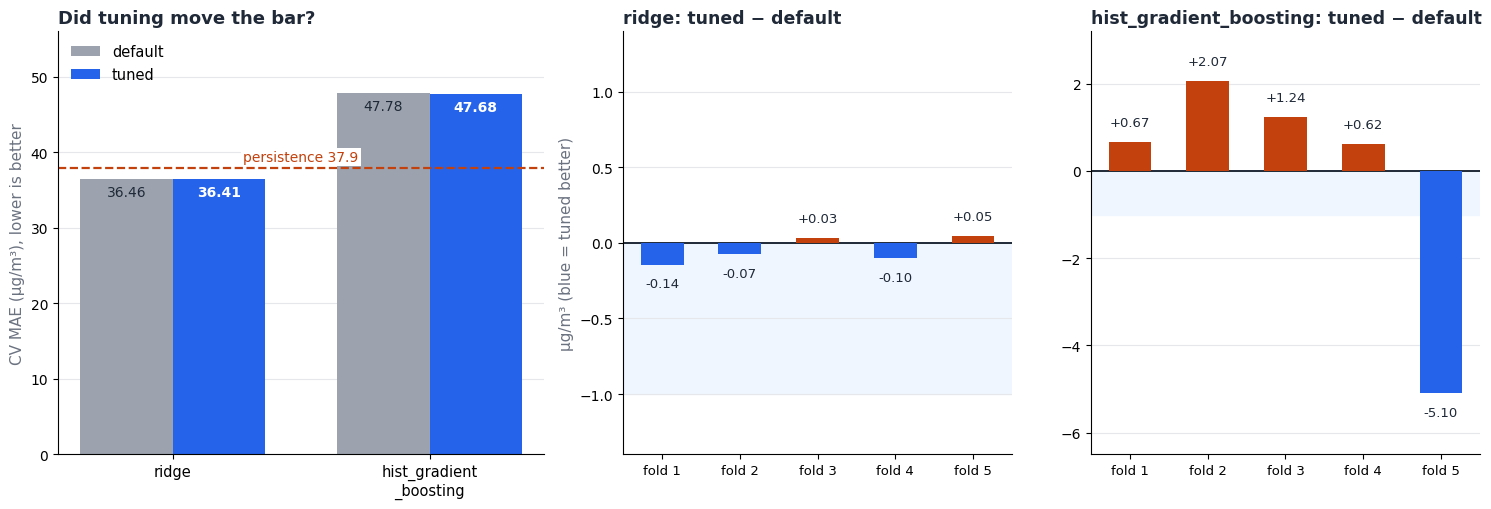

In [7]:
# Continues from Steps 3 to 5: default_cv, default_table, tuned_ridge_folds, tuned_tree_folds, best_alpha,
# best_tree_params, tree_name, ridge_results.
import numpy as np

# --- 1. The rule, written BEFORE the numbers are computed --------------------------------------
MIN_GAIN = 1.0       # tuning must lower the CV MAE by at least 1 µg/m³ ...
MIN_FOLDS = 4        # ... and must beat the default in at least 4 of the 5 mock tests

# --- 2. Tuned vs default for both students, fold by fold ---------------------------------------
pairs = {
    "ridge": (default_cv["ridge"], tuned_ridge_folds),
    tree_name: (default_cv[tree_name], tuned_tree_folds),
}
rows = {}
for name, (default_folds, tuned_folds) in pairs.items():
    gain = default_folds.mean() - tuned_folds.mean()
    folds_improved = int((tuned_folds < default_folds).sum())
    rows[name] = {
        "default CV MAE": default_folds.mean(),
        "tuned CV MAE": tuned_folds.mean(),
        "gain": gain,
        "gain %": 100 * gain / default_folds.mean(),
        "folds improved (of 5)": folds_improved,
        "worth keeping?": "yes" if gain >= MIN_GAIN and folds_improved >= MIN_FOLDS else "no",
    }
verdict = pd.DataFrame(rows).T
display(verdict.round(3))

# --- 3. What we will freeze: tuned settings only where the rule says yes ----------------------
default_tree_settings = {k: v for k, v in HistGradientBoostingRegressor().get_params().items()
                         if k in ("learning_rate", "max_depth", "min_samples_leaf", "max_iter")}
chosen_settings = {
    "ridge": {"alpha": best_alpha} if rows["ridge"]["worth keeping?"] == "yes" else {"alpha": 1.0},
    tree_name: best_tree_params if rows[tree_name]["worth keeping?"] == "yes" else default_tree_settings,
}
chosen_cv = {name: (rows[name]["tuned CV MAE"] if rows[name]["worth keeping?"] == "yes" else rows[name]["default CV MAE"])
             for name in rows}
print("settings we will freeze:", chosen_settings)

# --- 4. The full ranking, with persistence, on the same five folds -----------------------------
ranking = pd.Series({**{f"{name} (chosen settings)": mae for name, mae in chosen_cv.items()},
                     "persistence": default_table.loc["average", "persistence"]}).sort_values()
display(ranking.round(3).rename("CV MAE").to_frame())

# --- 5. Draw it: left = tuned vs default, then one panel per student, fold by fold ------------
fig, (left, mid, right) = plt.subplots(1, 3, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1.25, 1, 1]})
names = list(rows)
x_pos = np.arange(len(names))
left.bar(x_pos - 0.18, [rows[n]["default CV MAE"] for n in names], 0.36, color=rs.BAR, label="default")
left.bar(x_pos + 0.18, [rows[n]["tuned CV MAE"] for n in names], 0.36, color=rs.ACCENT, label="tuned")
for i, n in enumerate(names):                                           # numbers inside the bars, away from the dashed line
    left.text(i - 0.18, rows[n]["default CV MAE"] - 2.2, f"{rows[n]['default CV MAE']:.2f}", ha="center", fontsize=10, color=rs.INK)
    left.text(i + 0.18, rows[n]["tuned CV MAE"] - 2.2, f"{rows[n]['tuned CV MAE']:.2f}", ha="center", fontsize=10, color="white", fontweight="bold")
left.axhline(default_table.loc["average", "persistence"], color=rs.ALERT, ls="--", lw=1.6)
left.text(0.5, default_table.loc["average", "persistence"] + 1.0, f"persistence {default_table.loc['average', 'persistence']:.1f}",
          color=rs.ALERT, fontsize=10, ha="center", bbox=dict(fc="white", ec="none", pad=1.5))
left.set_xticks(x_pos); left.set_xticklabels(["ridge", "hist_gradient\n_boosting"], fontsize=10.5); left.set_ylim(0, 56)
left.set_ylabel("CV MAE (µg/m³), lower is better", fontsize=11, color=rs.MUTED)
left.set_title("Did tuning move the bar?", loc="left", fontsize=13, fontweight="bold", color=rs.INK)
left.legend(frameon=False, fontsize=10.5, loc="upper left")

for panel, (name, (default_folds, tuned_folds)), limits in zip((mid, right), pairs.items(), ((-1.4, 1.4), (-6.5, 3.2))):
    diff = tuned_folds - default_folds                                  # negative = tuned is better in that fold
    panel.axhspan(-MIN_GAIN, 0, color=rs.ACCENT_FILL, zorder=0)         # the average fold must reach at least this far down
    panel.axhline(0, color=rs.INK, lw=1.4)
    panel.bar(range(1, 6), diff, color=[rs.ACCENT if d < 0 else rs.ALERT for d in diff], width=0.55, zorder=3)
    for k, d in enumerate(diff, start=1):
        panel.text(k, d + (0.12 if d >= 0 else -0.12) * (limits[1] - limits[0]) / 4, f"{d:+.2f}", ha="center",
                   va="bottom" if d >= 0 else "top", fontsize=9.5, color=rs.INK)
    panel.set_ylim(*limits); panel.set_xticks(range(1, 6)); panel.set_xticklabels([f"fold {k}" for k in range(1, 6)], fontsize=9.5)
    panel.set_title(f"{name}: tuned − default", loc="left", fontsize=12.5, fontweight="bold", color=rs.INK)
mid.set_ylabel("µg/m³ (blue = tuned better)", fontsize=11, color=rs.MUTED)
for ax_ in (left, mid, right):
    ax_.grid(axis="y", color=rs.GRID); ax_.set_axisbelow(True)
    for side in ("top", "right"):
        ax_.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

### What this code does, line by line

**Part 1 — the rule**

| Line | What it does |
|---|---|
| `MIN_GAIN = 1.0` | The smallest CV MAE improvement we accept, in µg/m³. Capital letters mean "a constant: do not change me" |
| `MIN_FOLDS = 4` | The smallest number of mock tests (out of 5) in which tuned must beat default |

These two lines come **before** any number is calculated. That is the whole point.

**Part 2 — tuned vs default for both students**

| Line | What it does |
|---|---|
| `pairs = {"ridge": (default_cv["ridge"], tuned_ridge_folds), tree_name: (...)}` | A dictionary: for each student, the pair (five default fold scores, five tuned fold scores). All five numbers come from Steps 3, 4 and 5 |
| `for name, (default_folds, tuned_folds) in pairs.items():` | Go through the two students. The brackets unpack the pair into the two arrays |
| `gain = default_folds.mean() - tuned_folds.mean()` | Default average minus tuned average. Positive = tuning helped |
| `folds_improved = int((tuned_folds < default_folds).sum())` | Compare the two arrays fold by fold. `<` gives True where tuned has the smaller error. `.sum()` counts the True |
| `"gain %": 100 * gain / default_folds.mean()` | The gain as a percentage of the default error, so the two students can be compared on one scale |
| `"worth keeping?": "yes" if gain >= MIN_GAIN and folds_improved >= MIN_FOLDS else "no"` | **The rule, applied.** Both parts must be true, because of `and`. Anything else is "no" |
| `verdict = pd.DataFrame(rows).T` | Turn the dictionary into a table. `.T` means "transpose": swap rows and columns, so each student is one row |

**Part 3 — what we will freeze**

| Line | What it does |
|---|---|
| `HistGradientBoostingRegressor().get_params()` | Ask a fresh, default boosting model for all its settings. It returns a dictionary |
| `{k: v for k, v in ... if k in (...)}` | Keep only the four knobs we tuned, so we have the **default values written out in full** (learning rate 0.1, no depth limit, 20 days per leaf, 100 rounds) |
| `chosen_settings = {...}` | For each student: if the rule said "yes", the tuned settings; otherwise the default ones. `A if condition else B` is Python's one-line choice |
| `chosen_cv = {...}` | The CV MAE that goes with the chosen settings, picked the same way |

**Part 4 — the full ranking**

| Line | What it does |
|---|---|
| `{**{...}, "persistence": ...}` | Merge two dictionaries into one. `**` spreads the contents of the first one. The result: both students (with chosen settings) plus persistence |
| `pd.Series(...).sort_values()` | One column of marks, best (lowest) on top |
| `.rename("CV MAE").to_frame()` | Give the column a name and show it as a table |

**Part 5 — the picture**

| Line | What it does |
|---|---|
| `plt.subplots(1, 3, ..., gridspec_kw={"width_ratios": [1.25, 1, 1]})` | Three charts in one row. The first is a little wider |
| `left.bar(x_pos - 0.18, ...)` and `left.bar(x_pos + 0.18, ...)` | Two bars per student, side by side: default in grey, tuned in blue. The numbers are written **inside** the bars, so they do not collide with the dashed line |
| `left.axhline(persistence, ...)` | The persistence mark as a dashed line. A student must be below this line to be worth using |
| `for panel, (name, (default_folds, tuned_folds)), limits in zip((mid, right), pairs.items(), (...)):` | One panel per student. `zip` walks the three lists together: the panel, the data and the vertical range. Each panel has its **own** range, so Ridge's tiny differences do not get squashed by boosting's big one |
| `diff = tuned_folds - default_folds` | Tuned minus default, per fold. **Negative is good** (smaller error) |
| `panel.axhspan(-MIN_GAIN, 0, ...)` | The light-blue band from 0 down to −1.0. This is what a real gain should look like: the bars should reach into the band |
| `panel.bar(range(1, 6), diff, color=[blue if d < 0 else red ...])` | One bar per fold: blue where tuned won, red where it lost |
| `panel.text(k, d + ..., f"{d:+.2f}", ...)` | Write each difference on its bar. `:+.2f` means "two decimals, always with a + or − sign" |

### Read the result

| | Default | Tuned | Gain | Gain % | Folds improved | Rule says |
|---|---:|---:|---:|---:|---:|---|
| **Ridge** | 36.456 | 36.409 | 0.047 | 0.13% | 3 of 5 | **no** (gain far below 1.0) |
| **HistGradientBoosting** | 47.782 | 47.683 | 0.099 | 0.21% | 1 of 5 | **no** (gain below 1.0, and 1 fold is less than 4) |

**Both coachings fail the rule, so we keep the defaults.** The settings we will freeze are:

- Ridge: `alpha = 1.0`
- HistGradientBoosting: `learning_rate = 0.1`, `max_depth = None`, `min_samples_leaf = 20`, `max_iter = 100`

The picture shows why:

- **Ridge (middle):** all five bars are tiny, between −0.14 and +0.05. The light-blue band, the size of a real gain, is about 7 times deeper than the deepest bar. Three bars are blue and two red, which is what you get from noise.
- **HistGradientBoosting (right):** four red bars (tuned is worse by 0.6 to 2.1) and one big blue bar in fold 5 (−5.10). **All of the "gain" comes from one fold.** Without fold 5 the tuned model is worse.

**Explain-back question 2: "How much did tuning help, and was it worth the complexity?"**

> Tuning helped by **0.047 µg/m³ for Ridge (0.13%)** and **0.099 µg/m³ for HistGradientBoosting (0.21%)**. That is less than a hundredth of the gap between the models, and much less than the fold-to-fold swing of tens of µg/m³. It was **not** worth the complexity. We spent 100 and 150 mock tests to learn that **the default settings were already in the flat part of the curve**. That is still a useful finding: it tells us the models are not sensitive to their knobs, so the result will not break if the settings are a little off.

**The full ranking, on the same five folds:**

| Rank | Student (chosen settings) | CV MAE |
|---:|---|---:|
| 1 | Ridge | 36.456 |
| 2 | Persistence | 37.889 |
| 3 | HistGradientBoosting | 47.782 |

**A warning for Step 7.** Ridge beats persistence by only 1.43 µg/m³ on the average, and Step 3's table shows it **loses to persistence in 2 of the 5 mock tests** (fold 1: 31.9 against 17.1, fold 2: 14.7 against 11.2). It wins folds 3, 4 and 5, the smog-season ones, which are the ones that matter for Asha's decision. Step 7 has to look at this honestly before it freezes Ridge.

**Acceptance criteria:** ✅ Tuned vs default CV MAE is reported for both models, and a rule decided what it means. ✅ No test row was used in this step.

## Before Step 7

Step 6 gave us `chosen_settings` (both default, by the rule) and a ranking: Ridge 36.456, persistence 37.889, HistGradientBoosting 47.782. Step 7 chooses the **final model** and writes it into `models/final_config.json` before DAF-18 opens the test days. Two questions will have to be answered there: is Ridge really better than the lazy persistence student, given that it loses 2 of the 5 mock tests? And what exactly must the config file contain so that DAF-18 can rebuild the model without anyone's memory?

# Step 7 — Sign the hall ticket: choose the final student and freeze it

## 🎬 How we got here

**Where Asha madam stands after Step 6:**

| Student | CV MAE (average of 5 mock tests) | Settings |
|---|---:|---|
| Ridge | 36.456 | default, `alpha = 1.0` (tuning did not pass the rule) |
| Persistence (the lazy student) | 37.889 | none, it copies today |
| HistGradientBoosting | 47.782 | default (tuning did not pass the rule) |

Now she has to pick **one** student to send to the board exam in DAF-18.

---

**Asha:** Sir, it is easy. Ridge has the lowest number. I pick Ridge.

**Sharma sir:** Ridge is 36.456 and the lazy student is 37.889. How much is the difference?

**Asha:** About 1.4.

**Sharma sir:** And in the five mock tests, how many did Ridge win against the lazy student?

**Asha:** *(checks Step 3)* Three. Tests 3, 4 and 5. In tests 1 and 2 the lazy student was better.

**Sharma sir:** So the clever student wins by a small margin and loses two of five tests. Is that enough to say "pick Ridge"?

**Asha:** Hmm. The tests Ridge won are the smog months, sir. Those matter most for the children's decision.

**Sharma sir:** Good thinking. But again, **write the rule first.** What must the final student do to be picked?

**Asha:** It must have the best average mark among the trained students. And it must beat the lazy student on the average, and also in at least 3 of the 5 tests, so it is not winning by one lucky test.

**Sharma sir:** Write it. And if nobody passes?

**Asha:** Then the honest answer is "use the lazy student", and I say so.

**Sharma sir:** Good. Now the second thing. Suppose you fall sick on the exam day. Can someone else send the right student to the exam hall, with the right settings, just from your notes?

**Asha:** If I write everything down properly, yes.

**Sharma sir:** That paper is the **hall ticket**: name, roll number, subjects, everything. And once it is signed, nobody changes a word. Then, and only then, you open the board paper.

---

## 😖 The problem

Two risks:

1. **Choosing by feeling.** "Ridge looks best" is not a rule. After DAF-18, someone will ask why Ridge, and the answer must be on paper.
2. **A model that lives only in a notebook.** The settings are in variables that disappear when the notebook closes. DAF-18 and the API service (DAF-19 to DAF-21) need the exact recipe. If it is typed again from memory, one wrong number and the scores no longer match.

## 💡 The fix: a rule, and a hall ticket (`models/final_config.json`)

```text
rule  ──►  pick the final model  ──►  write everything in final_config.json  ──►  rebuild from the file alone
                                                                                   and check the marks match
```

What goes into the hall ticket:

| Field | Why it is there |
|---|---|
| model and settings | what exactly to build: scaler + Ridge, `alpha = 1.0`, `solver = lsqr` |
| features | the four inputs, in order |
| train rows, dates, and a **fingerprint** of the target (`sha256`) | proof that DAF-18 trains on the very same 251 days. The fingerprint is like a seal on an envelope: if one number changes, the seal changes |
| locked test: cut date, 130 rows not used | a written promise that the board paper was not opened |
| CV marks, fold by fold, and persistence | the "before the exam" evidence, to compare with the exam result |
| tuning: default vs tuned, which one was kept | the story of Steps 4 to 6 in three lines |
| `sklearn_version` | a model can behave a little differently in another version |
| `frozen_on` | the date of signing |

**Frozen means frozen.** If the file already exists, the code does not overwrite it. It checks that the recipe is identical, and stops with an error if not.

## What we do in this step

1. Write the rule: the best trained student must beat persistence on average **and** in at least 3 of 5 folds.
2. Apply it and name the final model.
3. Build the config dictionary and write it to `models/final_config.json`, once.
4. **Prove the file is enough:** rebuild the model from the JSON only, score it on the five folds, and check the marks are the same.

**What "done" looks like:** `models/final_config.json` exists, the rebuilt model reproduces 36.456 on all five folds, and acceptance criterion 4 is ticked.

In [8]:
# Continues from Steps 1 to 6: train, X, y, splits, feature_names, CUT_DATE, n_locked, data_root, default_cv, default_table,
# pairs, verdict, chosen_settings, chosen_cv, tree_name.
import hashlib
import json
from datetime import date

import sklearn

# --- 1. The rule for the final model, written BEFORE the numbers are looked at -----------------
MIN_FOLD_WINS = 3     # the final model must beat persistence on the average AND in at least 3 of the 5 mock tests

# --- 2. The two trained students, each with the settings Step 6 chose ---------------------------
chosen_folds = {name: (tuned if verdict.loc[name, "worth keeping?"] == "yes" else default)
                for name, (default, tuned) in pairs.items()}          # five fold scores per student
final_name = min(chosen_cv, key=chosen_cv.get)                         # lowest average CV MAE wins
persistence_folds = default_cv["persistence"]
fold_wins = int((chosen_folds[final_name] < persistence_folds).sum())
beats_persistence = chosen_cv[final_name] < persistence_folds.mean() and fold_wins >= MIN_FOLD_WINS
print(f"final model: {final_name}  (CV MAE {chosen_cv[final_name]:.3f}, persistence {persistence_folds.mean():.3f}, "
      f"beats persistence in {fold_wins} of 5 folds)")
assert beats_persistence, "the best trained model does not beat persistence: the honest answer is persistence"

# --- 3. Write the whole recipe into one dictionary ---------------------------------------------
recipes = {
    "ridge": {"steps": [["StandardScaler", {}], ["Ridge", {"solver": "lsqr", **chosen_settings["ridge"]}]]},
    tree_name: {"steps": [["HistGradientBoostingRegressor", {"random_state": 0, **chosen_settings[tree_name]}]]},
}
final_config = {
    "frozen_on": str(date.today()),
    "ticket": "DAF-17",
    "model": {"name": final_name, **recipes[final_name]},
    "features": feature_names,
    "target": "target",
    "poor_line": 91,
    "train": {
        "rows": len(train),
        "first_date": str(train.index.min().date()),
        "last_date": str(train.index.max().date()),
        "target_sha256": hashlib.sha256(train["target"].round(6).to_numpy().tobytes()).hexdigest(),   # fingerprint of the train data
    },
    "locked_test": {"cut_date": str(CUT_DATE.date()), "rows_not_used": n_locked},
    "cv": {
        "method": "TimeSeriesSplit",
        "n_splits": 5,
        "fold_mae": [round(float(v), 4) for v in chosen_folds[final_name]],
        "mean_mae": round(float(chosen_cv[final_name]), 4),
        "persistence_mean_mae": round(float(persistence_folds.mean()), 4),
        "folds_better_than_persistence": fold_wins,
    },
    "tuning": {name: {"default_cv": round(float(verdict.loc[name, "default CV MAE"]), 4),
                      "tuned_cv": round(float(verdict.loc[name, "tuned CV MAE"]), 4),
                      "kept": "tuned" if verdict.loc[name, "worth keeping?"] == "yes" else "default"} for name in verdict.index},
    "sklearn_version": sklearn.__version__,
}

# --- 4. Freeze it: write once, and refuse to change it afterwards ------------------------------
config_path = data_root.parent / "models" / "final_config.json"
config_path.parent.mkdir(exist_ok=True)
if config_path.exists():                                              # already frozen: it must be the same recipe
    frozen = json.loads(config_path.read_text())
    assert {**frozen, "frozen_on": None} == {**final_config, "frozen_on": None}, "the frozen config would change: DAF-17 is already closed"
    print("already frozen on", frozen["frozen_on"], "- identical, nothing rewritten")
else:
    config_path.write_text(json.dumps(final_config, indent=2) + "\n")
    print("frozen to", config_path.relative_to(data_root.parent))
print(config_path.read_text())

# --- 5. Prove the file alone is enough: rebuild the model from the JSON and re-score it --------
from sklearn.base import clone

def build_model(config):
    """Make an unfitted model from the config file and nothing else."""
    parts = {"StandardScaler": StandardScaler, "Ridge": Ridge, "HistGradientBoostingRegressor": HistGradientBoostingRegressor}
    steps = [(f"step{i}", parts[kind](**settings)) for i, (kind, settings) in enumerate(config["model"]["steps"])]
    return Pipeline(steps) if len(steps) > 1 else steps[0][1]

frozen = json.loads(config_path.read_text())
rebuilt = build_model(frozen)
rebuilt_folds = -cross_val_score(clone(rebuilt), train[frozen["features"]], train[frozen["target"]], cv=splits, scoring="neg_mean_absolute_error")
assert np.allclose(rebuilt_folds, chosen_folds[final_name]), "the rebuilt model does not reproduce the Step 6 scores"
print(f"rebuilt from the file: CV MAE {rebuilt_folds.mean():.3f}  (Step 6 said {chosen_cv[final_name]:.3f})  -> same on all 5 folds")
assert frozen["train"]["rows"] == len(train) and frozen["locked_test"]["rows_not_used"] == 130

final model: ridge  (CV MAE 36.456, persistence 37.889, beats persistence in 3 of 5 folds)
already frozen on 2026-10-03 - identical, nothing rewritten
{
  "frozen_on": "2026-10-03",
  "ticket": "DAF-17",
  "model": {
    "name": "ridge",
    "steps": [
      [
        "StandardScaler",
        {}
      ],
      [
        "Ridge",
        {
          "solver": "lsqr",
          "alpha": 1.0
        }
      ]
    ]
  },
  "features": [
    "pm25_until_17",
    "mean_3",
    "mean_7",
    "mean_14"
  ],
  "target": "target",
  "poor_line": 91,
  "train": {
    "rows": 251,
    "first_date": "2025-03-17",
    "last_date": "2026-02-28",
    "target_sha256": "4becfde856706a349111384ef69d538bed008ca56e539528669abd51c949a7ec"
  },
  "locked_test": {
    "cut_date": "2026-03-01",
    "rows_not_used": 130
  },
  "cv": {
    "method": "TimeSeriesSplit",
    "n_splits": 5,
    "fold_mae": [
      31.8979,
      14.6577,
      46.3532,
      52.356,
      37.0174
    ],
    "mean_mae": 36.4564,
   

### What this code does, line by line

**Part 0 — imports**

| Line | What it does |
|---|---|
| `import hashlib` | Python's tool for making a **fingerprint** (hash) of any data. Same data gives the same fingerprint, a tiny change gives a completely different one |
| `import json` | Reads and writes JSON, a plain-text file format that any language (including the Java service later) can read |
| `from datetime import date` | To write today's date as the signing date |
| `import sklearn` | We only need it to read `sklearn.__version__` |

**Part 1 — the rule**

| Line | What it does |
|---|---|
| `MIN_FOLD_WINS = 3` | The rule's number: the final model must beat persistence in at least 3 of the 5 mock tests. Written first, in capitals |

**Part 2 — apply the rule**

| Line | What it does |
|---|---|
| `chosen_folds = {name: (tuned if verdict.loc[name, "worth keeping?"] == "yes" else default) for name, (default, tuned) in pairs.items()}` | For each student, take the five fold scores of the settings Step 6 chose: tuned if the verdict was "yes", default if "no". Both were "no", so these are the default scores |
| `final_name = min(chosen_cv, key=chosen_cv.get)` | `chosen_cv` is a dictionary of name → average mark. `min(..., key=chosen_cv.get)` returns the **name** with the smallest mark |
| `persistence_folds = default_cv["persistence"]` | The lazy student's five fold scores |
| `fold_wins = int((chosen_folds[final_name] < persistence_folds).sum())` | Compare fold by fold: in how many mock tests did the final student have the smaller error? |
| `beats_persistence = chosen_cv[final_name] < persistence_folds.mean() and fold_wins >= MIN_FOLD_WINS` | **The rule.** Both parts must be true: a lower average, and at least 3 fold wins |
| `assert beats_persistence, "..."` | If not, stop. It would mean the honest answer is "persistence", not a trained model |

**Part 3 — the recipe**

| Line | What it does |
|---|---|
| `recipes = {"ridge": {"steps": [["StandardScaler", {}], ["Ridge", {"solver": "lsqr", **chosen_settings["ridge"]}]]}, ...}` | A text description of each possible final model: a list of steps, each with its name and settings. `**chosen_settings["ridge"]` spreads `{"alpha": 1.0}` into the settings. Written as plain lists and dictionaries so it can be saved as JSON |
| `"model": {"name": final_name, **recipes[final_name]}` | Put the winner's recipe in the config |
| `hashlib.sha256(train["target"].round(6).to_numpy().tobytes()).hexdigest()` | The fingerprint. Round the target to 6 decimals (so tiny float noise does not matter), turn it into raw bytes, run it through SHA-256, and show the result as a text string of letters and digits |
| `"locked_test": {"cut_date": ..., "rows_not_used": n_locked}` | The written promise: the 130 days from 1 March were not used |
| `[round(float(v), 4) for v in chosen_folds[final_name]]` | The five fold marks as plain numbers with 4 decimals. `float(...)` converts numpy numbers, because JSON does not understand numpy |
| `"tuning": {name: {...} for name in verdict.index}` | For both students: default mark, tuned mark, and which one was kept. `verdict` is the table from Step 6 |
| `"sklearn_version": sklearn.__version__` | The library version used |

**Part 4 — freeze it**

| Line | What it does |
|---|---|
| `config_path = data_root.parent / "models" / "final_config.json"` | The file location. `data_root.parent` is the project folder, so `models/` sits next to `data/`. The `/` joins path parts |
| `config_path.parent.mkdir(exist_ok=True)` | Make the `models` folder if it does not exist. `exist_ok=True` means "no error if it is already there" |
| `if config_path.exists():` | Is the file already there? Then it is already frozen |
| `assert {**frozen, "frozen_on": None} == {**final_config, "frozen_on": None}, "..."` | Compare the old file with the new recipe, ignoring the signing date. If anything else differs, stop with an error. This is what "frozen" means in code |
| `config_path.write_text(json.dumps(final_config, indent=2) + "\n")` | First time only: turn the dictionary into JSON text (`indent=2` for easy reading) and save it |
| `print(config_path.read_text())` | Show the file, so we read what was saved |

**Part 5 — prove the file alone is enough**

| Line | What it does |
|---|---|
| `def build_model(config):` | A function that makes an unfitted model from the config and **nothing else** |
| `parts = {"StandardScaler": StandardScaler, "Ridge": Ridge, ...}` | A lookup: the name written in the JSON → the real class in Python |
| `steps = [(f"step{i}", parts[kind](**settings)) for i, (kind, settings) in enumerate(config["model"]["steps"])]` | For each step in the recipe: find its class, and create it with its settings. `**settings` unpacks the dictionary into named arguments, so `{"alpha": 1.0}` becomes `Ridge(alpha=1.0)` |
| `return Pipeline(steps) if len(steps) > 1 else steps[0][1]` | More than one step (scaler + Ridge) becomes a `Pipeline`. One step is used as it is |
| `frozen = json.loads(config_path.read_text())` | Read the file back from disk, as DAF-18 will |
| `cross_val_score(clone(rebuilt), ..., cv=splits, ...)` | Score the rebuilt model on the five honest folds. `clone` makes a fresh copy, so nothing is left over from earlier fits |
| `assert np.allclose(rebuilt_folds, chosen_folds[final_name]), "..."` | The rebuilt model must give the **same five marks** as in Step 6. `allclose` means "equal, apart from tiny rounding" |
| `assert frozen["train"]["rows"] == len(train) and ...` | The last check: the file says 251 train rows and 130 locked rows, and that matches |

### Read the result

**The rule picked Ridge.**

| Check (written before the run) | Result |
|---|---|
| Lowest average CV MAE among the trained students | Ridge 36.456 (boosting 47.782) |
| Beats persistence on the average | 36.456 < 37.889 ✅ |
| Beats persistence in at least 3 of 5 folds | 3 of 5 ✅ (folds 3, 4, 5, the smog months) |

**Frozen to `models/final_config.json`:** a scaler plus `Ridge(alpha=1.0, solver="lsqr")`, the four features, 251 train days (17 Mar 2025 to 28 Feb 2026), the fingerprint of the target, and the written promise that 130 days from 1 March 2026 were not used. The rebuilt-from-file model gave **36.456, the same on all five folds**, so the file is a complete recipe.

Five things worth knowing, before DAF-18:

- **The margin is small.** Ridge beats persistence by 1.43 µg/m³ (3.8%). The notebook does not claim more than that. DAF-18 will tell us how it does on days it never saw.
- **Ridge wins where it matters, and loses where it does not.** It won the smog folds (3, 4, 5), where a wrong forecast sends children outside into bad air. It lost folds 1 and 2 (June to September: few Poor days), where "tomorrow = today" is hard to beat.
- **The test period looks more like folds 1 and 2 than 3 to 5.** It runs from March to August, with only 17 Poor days in 130. So persistence may be close to Ridge there. That is not a reason to change the choice now. It is something to **report honestly** in DAF-18.
- **The 130 days are not completely fresh.** DAF-06 to DAF-16 already scored models on them, so DAF-18 will be the last look, not the first. The model card should say this plainly.
- **The signature is real.** If you run this notebook again, the code does not rewrite the file. It checks that the recipe is identical and says "already frozen". Try changing `MIN_FOLD_WINS` to 4 and re-run: Ridge (3 fold wins) no longer passes the rule, so the notebook stops with an error, and the file on disk is left as it was.

**Acceptance criteria:**
- ✅ The fold plot shows every validation fold after its training fold (Step 2)
- ✅ No test row is used anywhere in this notebook, shown in code (the asserts of Steps 1 and 2, and `train` is the only table)
- ✅ Tuned vs default CV MAE is reported for both models (Steps 4 to 6)
- ✅ The final model and its settings are frozen before DAF-18 opens (this step)

## Before Step 8

Step 7 froze the final model: Ridge, default settings, in `models/final_config.json`. Step 8 writes the evidence into the project log (`reports/experiments.csv`): one row per student with its CV MAE, so that DAF-18 has the "before the exam" numbers to compare with. After that, a short recap closes the ticket. We will also write the decision into `docs/decisions/` as D-007, because this is a choice that someone will ask about later.

# Step 8 — Write the evidence in the register

## 🎬 How we got here

Steps 1 to 7 finished the work: five honest folds, two students coached, a rule that said "no" twice, and a signed hall ticket for Ridge. Asha madam is about to close her laptop.

---

**Sharma sir:** Hall ticket is signed. Good. Now, in DAF-18 you will open the board paper. When the result comes, what will you compare it with?

**Asha:** With the marks from the mock tests, sir.

**Sharma sir:** Where will you read those marks from? This notebook will be closed.

**Asha:** Hmm. From my memory... or I can run the notebook again.

**Sharma sir:** *(shakes his head)* A school does not run the exams again to find last year's marks. It keeps a **register**. Each exam, each student, each mark, written once. You already have a register in this project. What is it called?

**Asha:** `reports/experiments.csv`, sir.

**Sharma sir:** Then write the mock-test marks there. But be careful. How many kinds of exam are in the register now?

**Asha:** *(counts)* Three. DAF-06 to DAF-15 used one cut date and 130 test days. DAF-16 used walk-forward, 11 monthly exams. And now DAF-17: five cross-validation folds on the train days.

**Sharma sir:** Can you put them in one list and say "this one has the lowest error, so it is the best"?

**Asha:** No sir. Different exams, different papers. The marks are not comparable.

**Sharma sir:** Then every row must say which exam it was. Also, your register has a column for Poor-day recall, because that is what the children's decision depends on. In DAF-17 you scored only the error. Fill that column too. It costs you ten lines.

---

## 😖 The problem

After this step the log holds **three kinds of row**:

```text
DAF-06 to DAF-15   one cut date, 130 test days (spring and summer)     ← the test days
DAF-16             11 monthly exams, 246 days (a whole winter)         ← walk-forward
DAF-17             5 folds on the 251 train days                       ← cross-validation, NEW

same columns (mae, recall_poor), DIFFERENT exams
```

Also, DAF-17 measured only MAE so far. The log's `recall_poor` column needs a number, and it should be measured the same way for every row of this ticket.

## 💡 The idea

1. **Forecast every validation day** of the five folds with a model that never saw that day, for each student. That gives 205 forecasts per student (5 folds × 41 days), 106 of them on really Poor days.
2. **Recall** = of those 106 Poor days, how many did the forecast warn about (forecast of 91 or more)?
3. Add **five rows**: Ridge default, Ridge tuned, boosting default, boosting tuned, and persistence. Every note says `TimeSeriesSplit` and `not comparable with single-cut or walk-forward rows`.
4. **Re-run safe:** old DAF-17 rows are removed first. Other tickets' rows are checked to be unchanged.

### 🤔 Before you run the code

Ridge default and Ridge tuned have different alphas (1.0 and 0.013). Do you expect their **recall** to be different? And do you expect Ridge to catch clearly more Poor days than the lazy persistence student? Think, then read the result.

In [9]:
# Continues from Steps 1 to 7: train, X, y, splits, feature_names, default_cv, default_table, pairs, verdict, ridge_search,
# tree_search, tree_name, frozen, data_root, clone.

log_path = data_root.parent / "reports/experiments.csv"
log_columns = ["ticket", "date", "model", "features", "mae", "recall_poor", "notes"]

# --- 1. Forecast every validation day of the five folds, each from a model that never saw it ----
def cv_forecasts(model):
    """One forecast per validation day: the model is refitted on each fold's study rows only."""
    predicted = pd.Series(np.nan, index=y.index)
    for train_pos, valid_pos in splits:
        fitted = clone(model).fit(X.iloc[train_pos], y.iloc[train_pos])
        predicted.iloc[valid_pos] = fitted.predict(X.iloc[valid_pos])
    return predicted.dropna()

def poor_recall(predicted):
    """Of the really Poor days (target 91 or more), what share did the forecast warn about (forecast 91 or more)?"""
    really_poor = y.loc[predicted.index] >= 91
    warned = predicted >= 91
    return (really_poor & warned).sum() / really_poor.sum()

# --- 2. The five rows: both students, default and tuned, plus persistence ------------------------
tuned_ridge = Pipeline([("scale", StandardScaler()), ("model", Ridge(solver="lsqr", alpha=ridge_search.best_params_["model__alpha"]))])
students = {
    "ridge_default":       (build_model(frozen), default_cv["ridge"].mean(), "StandardScaler+Ridge(alpha=1.0, solver=lsqr)",
                            "FINAL model: frozen in models/final_config.json, D-007"),
    "ridge_tuned":         (tuned_ridge, pairs["ridge"][1].mean(), f"StandardScaler+Ridge(alpha={ridge_search.best_params_['model__alpha']:.3f}, solver=lsqr)",
                            "not kept: gain 0.047 is below the 1.0 rule, 3 of 5 folds"),
    "hgb_default":         (HistGradientBoostingRegressor(random_state=0), default_cv[tree_name].mean(), "HistGradientBoostingRegressor defaults, random_state=0",
                            "tree candidate, not final"),
    "hgb_tuned":           (HistGradientBoostingRegressor(random_state=0, **tree_search.best_params_), pairs[tree_name][1].mean(),
                            f"HistGradientBoostingRegressor {best_tree_params}, random_state=0", "not kept: gain 0.099 is below the 1.0 rule, 1 of 5 folds"),
}
valid_rows = np.concatenate([valid_pos for _, valid_pos in splits])
persistence_forecast = X["pm25_until_17"].iloc[valid_rows]
n_valid, n_poor_valid = len(valid_rows), int((y.iloc[valid_rows] >= 91).sum())

def make_row(name, features_note, mae, recall, role):
    return {
        "ticket": "DAF-17",
        "date": pd.Timestamp.today().strftime("%Y-%m-%d"),
        "model": f"daf17_{name}_cv",
        "features": ", ".join(feature_names),
        "mae": round(float(mae), 3),
        "recall_poor": round(float(recall), 3),
        "notes": (f"cross-validation: TimeSeriesSplit 5 folds on {len(train)} train rows "
                  f"({train.index.min().date()} to {train.index.max().date()}), test days not used; "
                  f"MAE = mean of 5 fold scores, recall pooled over {n_valid} validation days ({n_poor_valid} Poor, warn at 91); "
                  f"{features_note}; {role}; not comparable with single-cut or walk-forward rows"),
    }

new_rows = []
for name, (model, mae, description, role) in students.items():
    forecast = cv_forecasts(model)
    assert abs(mean_absolute_error(y.loc[forecast.index], forecast) - mae) < 1e-6, f"{name}: pooled MAE differs from the Step 3 to 6 numbers"
    new_rows.append(make_row(name, description, mae, poor_recall(forecast), role))
new_rows.append(make_row("persistence", "persistence, no fitting, forecast = pm25_until_17", default_table.loc["average", "persistence"],
                         poor_recall(persistence_forecast), "reference the final model must beat"))
new_rows = pd.DataFrame(new_rows, columns=log_columns)

# --- 3. Write them, safe to re-run ---------------------------------------------------------------
experiment_log = pd.read_csv(log_path)
other_rows = experiment_log.loc[experiment_log["ticket"] != "DAF-17"].reset_index(drop=True)
pd.concat([other_rows, new_rows], ignore_index=True)[log_columns].to_csv(log_path, index=False)
print(f"Wrote {len(new_rows)} DAF-17 rows to {log_path.relative_to(data_root.parent)}")

# --- 4. Safety checks: read the file back -------------------------------------------------------------
saved = pd.read_csv(log_path)
daf17 = saved.loc[saved["ticket"] == "DAF-17"]
assert len(daf17) == 5, "expected exactly five DAF-17 rows"
assert daf17["notes"].str.contains("TimeSeriesSplit").all(), "every row must say it is a cross-validation row"
assert saved.loc[saved["ticket"] != "DAF-17"].reset_index(drop=True).equals(other_rows), "rows from other tickets changed"
assert daf17.set_index("model").loc["daf17_ridge_default_cv", "mae"] == round(frozen["cv"]["mean_mae"], 3), "the log and the frozen config disagree"
print("5 rows, all marked cross-validation, other tickets untouched, final row matches final_config.json")

display(daf17[["model", "mae", "recall_poor"]].set_index("model"))
print("The full note for the final model:")
print(daf17.set_index("model").loc["daf17_ridge_default_cv", "notes"])

Wrote 5 DAF-17 rows to reports/experiments.csv
5 rows, all marked cross-validation, other tickets untouched, final row matches final_config.json


,mae,recall_poor
model,,
daf17_ridge_default_cv,36.456,0.915
daf17_ridge_tuned_cv,36.409,0.915
daf17_hgb_default_cv,47.782,0.774
daf17_hgb_tuned_cv,47.683,0.774
daf17_persistence_cv,37.889,0.906


The full note for the final model:
cross-validation: TimeSeriesSplit 5 folds on 251 train rows (2025-03-17 to 2026-02-28), test days not used; MAE = mean of 5 fold scores, recall pooled over 205 validation days (106 Poor, warn at 91); StandardScaler+Ridge(alpha=1.0, solver=lsqr); FINAL model: frozen in models/final_config.json, D-007; not comparable with single-cut or walk-forward rows


### What this code does, line by line

**Part 1 — forecast every validation day**

| Line | What it does |
|---|---|
| `log_path = data_root.parent / "reports/experiments.csv"` | The register: the same file used since DAF-06 |
| `log_columns = [...]` | The seven columns every row must have |
| `def cv_forecasts(model):` | A function: give it a model, get one forecast per validation day |
| `predicted = pd.Series(np.nan, index=y.index)` | An empty list of forecasts for all 251 days, filled with "not a number" (`NaN`). Only the validation days will be filled |
| `for train_pos, valid_pos in splits:` | Go through our five honest folds |
| `fitted = clone(model).fit(X.iloc[train_pos], y.iloc[train_pos])` | Make a **fresh copy** of the model and teach it from this fold's study rows only |
| `predicted.iloc[valid_pos] = fitted.predict(X.iloc[valid_pos])` | Forecast this fold's test rows and store them at the right places |
| `return predicted.dropna()` | Remove the days that never were a validation day. The first 46 rows (study only) have no forecast. 205 are left |
| `def poor_recall(predicted):` | A function: of the really Poor days, what share did the forecast warn about? |
| `really_poor = y.loc[predicted.index] >= 91` | Mark the days that were really Poor, among the forecasted days |
| `warned = predicted >= 91` | Mark the days where the forecast was 91 or more |
| `(really_poor & warned).sum() / really_poor.sum()` | `&` keeps days that are both. Count them and divide by all the Poor days. That share is the recall |

**Part 2 — the five rows**

| Line | What it does |
|---|---|
| `tuned_ridge = Pipeline([... Ridge(solver="lsqr", alpha=ridge_search.best_params_["model__alpha"])])` | Ridge with the **tuned** alpha from Step 4, so the log can show the "tuned" row too |
| `students = {...}` | A dictionary: a name → (the model, its CV MAE, a description, and its role). The roles say which one is the final model and why the others were not kept |
| `build_model(frozen)` | The Ridge default is rebuilt **from the config file**, so the log row describes exactly what was frozen |
| `**tree_search.best_params_` | Spreads the winning boosting settings into the model's arguments |
| `valid_rows = np.concatenate([valid_pos for _, valid_pos in splits])` | Join the five lists of validation positions into one list of 205 |
| `persistence_forecast = X["pm25_until_17"].iloc[valid_rows]` | The lazy student's forecast for those days: today's value |
| `n_valid, n_poor_valid = ...` | 205 days and 106 Poor days, for the notes |
| `def make_row(name, features_note, mae, recall, role):` | Builds one log row as a dictionary: ticket, date, model name, features, MAE, recall, and a note that says how it was measured |
| `assert abs(mean_absolute_error(...) - mae) < 1e-6, "..."` | **A consistency check.** The pooled MAE of the new forecasts must equal the fold-average MAE of Steps 3 to 6. All folds have 41 days, so the two must agree. If not, the forecasts differ from what we studied |
| `round(float(mae), 3)` | Three decimals, as in every earlier row. `float(...)` removes the numpy wrapper |

**Part 3 — write safely**

| Line | What it does |
|---|---|
| `experiment_log = pd.read_csv(log_path)` | Read the register as it is |
| `other_rows = experiment_log.loc[experiment_log["ticket"] != "DAF-17"]` | Keep everything that is **not** a DAF-17 row. If we run again, the old DAF-17 rows disappear here, so no duplicates |
| `pd.concat([other_rows, new_rows])...to_csv(log_path, index=False)` | Stack old rows and new rows, and save. `index=False` leaves out the row numbers |

**Part 4 — read it back and check**

| Line | What it does |
|---|---|
| `assert len(daf17) == 5` | Exactly five rows, no more and no less |
| `assert daf17["notes"].str.contains("TimeSeriesSplit").all()` | Every row says it is a cross-validation row |
| `assert saved.loc[saved["ticket"] != "DAF-17"]...equals(other_rows)` | Every row of every other ticket is exactly as before |
| `assert ... == round(frozen["cv"]["mean_mae"], 3)` | The log's final row and `final_config.json` agree on the MAE |

### Read the result

Five rows were added to `reports/experiments.csv`, and the other 19 rows are exactly as they were.

| Model in the log | CV MAE | `recall_poor` | Role |
|---|---:|---:|---|
| `daf17_ridge_default_cv` | 36.456 | 0.915 | **final model**, frozen |
| `daf17_ridge_tuned_cv` | 36.409 | 0.915 | not kept |
| `daf17_persistence_cv` | 37.889 | 0.906 | reference |
| `daf17_hgb_default_cv` | 47.782 | 0.774 | tree candidate |
| `daf17_hgb_tuned_cv` | 47.683 | 0.774 | not kept |

**About the question before the code:**

- **Ridge default and tuned have the same recall (0.915).** Of the 106 Poor days, both warn about 97. A different alpha changed the error a little, but not one warning. That is one more reason to keep the simple default.
- **Ridge does not catch clearly more Poor days than persistence.** 97 against 96 of 106 (0.915 against 0.906). In recall they are almost the same. Ridge's real edge is a lower error (1.4 µg/m³) on the days, not more warnings. This matters for DAF-18: if the test result shows Ridge and persistence close on recall, that is **already expected** here.
- **Boosting is clearly behind on recall** (82 of 106, 0.774), as it was on MAE.

**Is it fair to rank these against the older rows?** No. These recall numbers come from 106 Poor days in autumn and winter, and the earlier rows come from 17 Poor days in spring and summer. This is why every note says `TimeSeriesSplit` and `not comparable with single-cut or walk-forward rows`.

### The ticket's acceptance criteria

| Criterion | Where it is met |
|---|---|
| The fold plot shows every validation fold after its training fold | Step 2: the timeline of five folds, and an `assert` on every fold |
| No test row is used anywhere in this notebook, shown in code | Step 1: the `del` and three `assert` lines. After that `train` is the only table |
| Tuned vs default CV MAE is reported for both models | Steps 4, 5 and 6: Ridge 36.456 vs 36.409, boosting 47.782 vs 47.683 |
| The final model and its settings are frozen before DAF-18 opens | Step 7: `models/final_config.json`, rebuilt from the file with the same marks |

### Explain-back: the numbers you will need

The ticket has two questions. The answers are yours to write, because they are the evidence for your skills record. These are the numbers from this notebook to use:

1. **Why does `KFold` with shuffle cheat on this data?** In Step 2, shuffled `KFold` made study piles that contained days **after** a test day in **5 of 5** folds. Picture 2 of the walkthrough: to predict 21 Nov (238), the model had already studied 20 Nov (221) and 22 Nov (270). Smog lasts for days, so the neighbours give the answer away.
2. **How much did tuning help, and was it worth the complexity?** Ridge: 36.456 to 36.409, a gain of 0.047 (0.13%). Boosting: 47.782 to 47.683, a gain of 0.099 (0.21%), all from one fold. Neither passed the rule (at least 1.0 and 4 of 5 folds). It cost 250 mock tests to learn that the defaults were already on the flat part of the curve.

The ticket file's **My notes** section is yours: *the final model and settings, and the CV improvement.*

## Before the Recap

All eight steps are done. The recap puts the whole notebook on two pictures.

# Recap — DAF-17 in one picture

Eight steps, one answer. Read this last, or come back to it in a month.

```text
Lock -> Folds -> Before marks -> Tune Ridge -> Tune boosting -> Worth it? -> Freeze -> Log
(Step 1) (Step 2)  (Step 3)       (Step 4)       (Step 5)        (Step 6)    (Step 7) (Step 8)
```

**How to read the pictures**

- **The cards** follow the notebook in order. Each one says what the step did and one number that came out of it. Orange cards are the two tunings that gave almost nothing. Blue cards are the freeze and the log.
- **First picture, left chart:** default against tuned for both students, with persistence as the dashed line to beat.
- **First picture, right chart:** the five mock tests one by one: Ridge, persistence and boosting. The number of Poor days is under each fold.
- **Second picture, left chart:** the five rows read back from `reports/experiments.csv`, with recall inside each bar.
- **Second picture, right chart:** how hard each mock test was, and Ridge's mark on it.

Every number is read from the earlier cells or from the saved log, so run the notebook from the top.

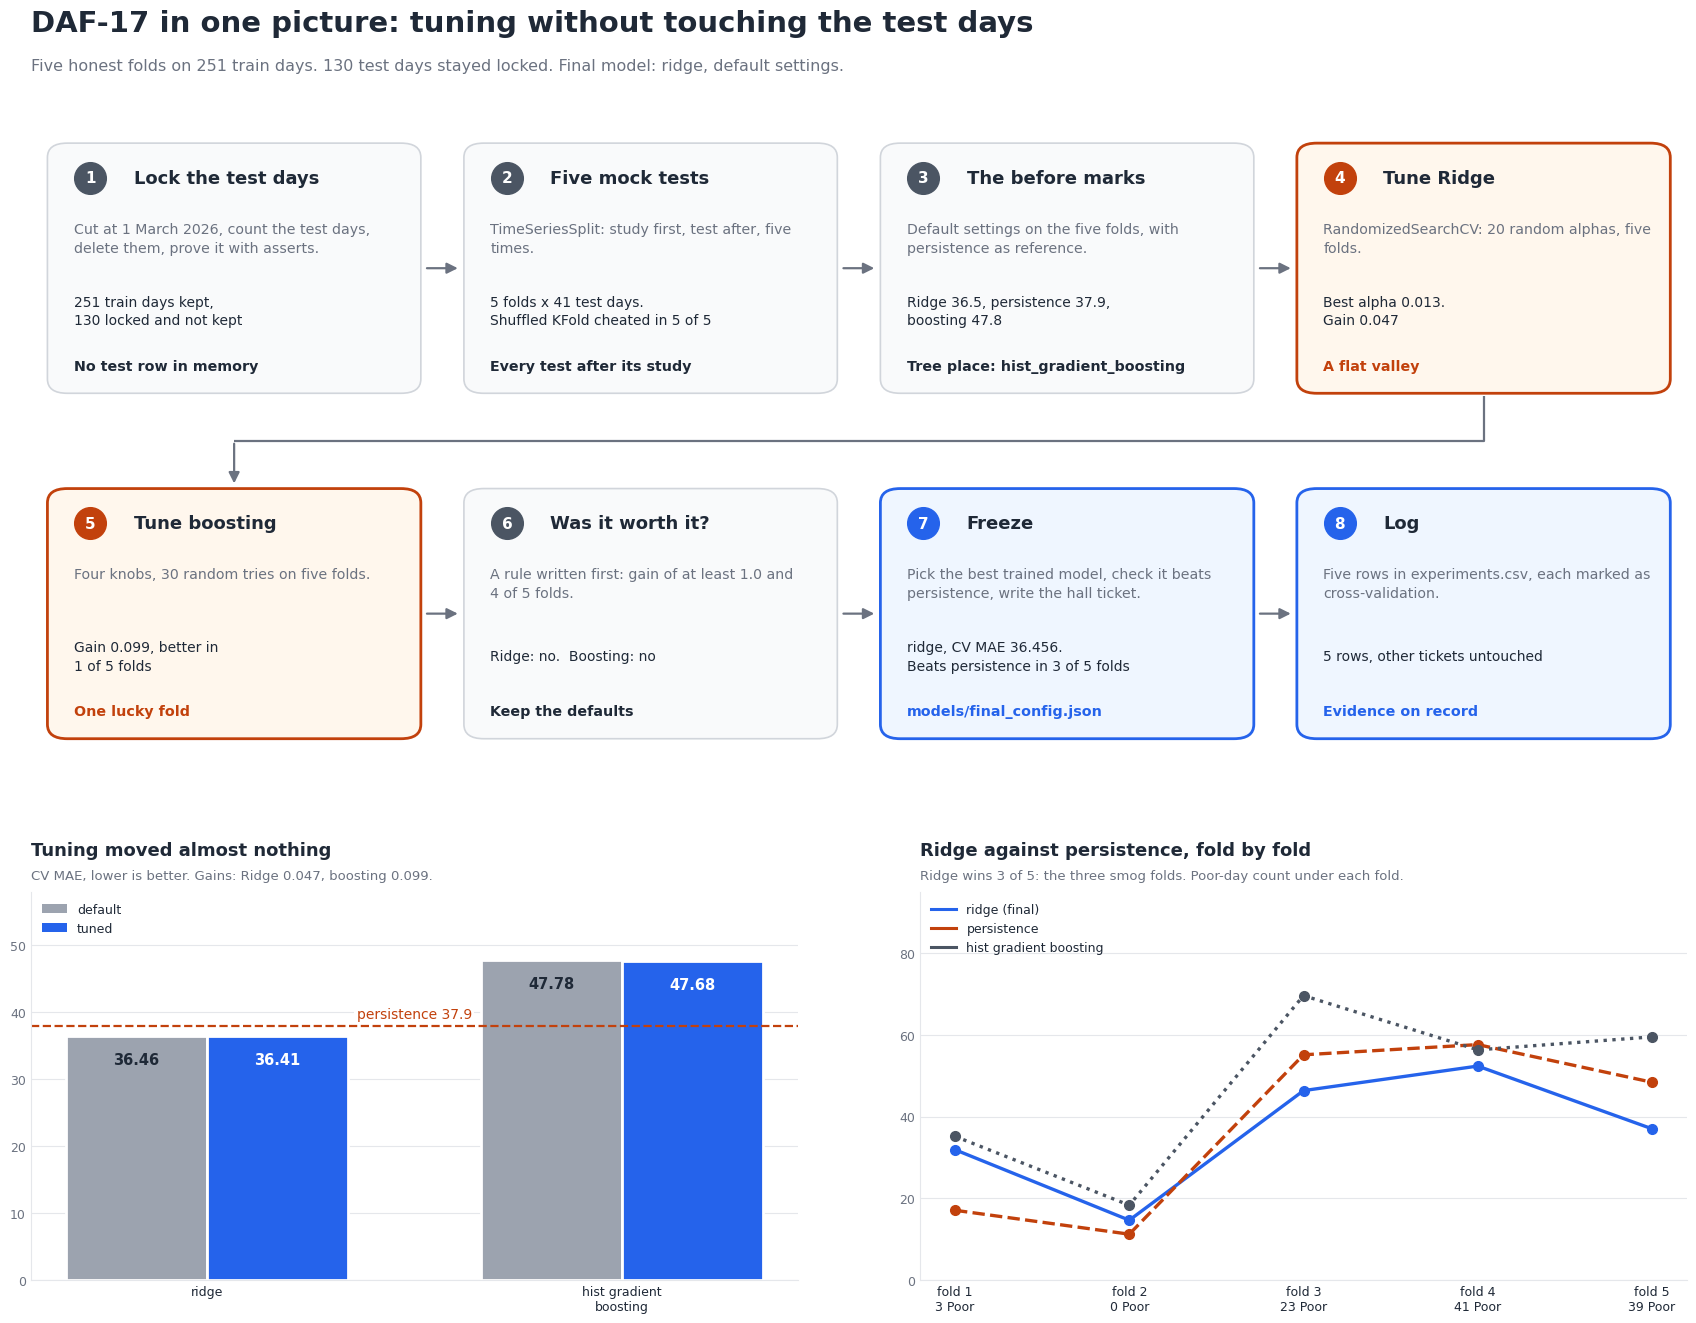

In [10]:
import matplotlib.pyplot as plt

import recap_style as rs

# Continues from Steps 1 to 8. Nothing is typed in by hand: every number comes from an earlier variable.
ridge_gain = verdict.loc["ridge", "gain"]
tree_gain = verdict.loc[tree_name, "gain"]
average = default_table.loc["average"]

cards = [
    dict(badge="1", title="Lock the test days", adds="Cut at 1 March 2026, count the test days, delete them, prove it with asserts.",
         numbers=f"{len(train)} train days kept,\n{n_locked} locked and not kept", verdict="No test row in memory"),
    dict(badge="2", title="Five mock tests", adds="TimeSeriesSplit: study first, test after, five times.",
         numbers=f"5 folds x {int(folds['valid_rows'].iloc[0])} test days.\nShuffled KFold cheated in 5 of 5", verdict="Every test after its study"),
    dict(badge="3", title="The before marks", adds="Default settings on the five folds, with persistence as reference.",
         numbers=f"Ridge {average['ridge']:.1f}, persistence {average['persistence']:.1f},\nboosting {average['hist_gradient_boosting']:.1f}", verdict=f"Tree place: {tree_name}"),
    dict(badge="4", title="Tune Ridge", adds="RandomizedSearchCV: 20 random alphas, five folds.",
         numbers=f"Best alpha {best_alpha:.3f}.\nGain {ridge_gain:.3f}", verdict="A flat valley", kind="problem"),
    dict(badge="5", title="Tune boosting", adds="Four knobs, 30 random tries on five folds.",
         numbers=f"Gain {tree_gain:.3f}, better in\n{verdict.loc[tree_name, 'folds improved (of 5)']} of 5 folds", verdict="One lucky fold", kind="problem"),
    dict(badge="6", title="Was it worth it?", adds="A rule written first: gain of at least 1.0 and 4 of 5 folds.",
         numbers=f"Ridge: {verdict.loc['ridge', 'worth keeping?']}.  Boosting: {verdict.loc[tree_name, 'worth keeping?']}", verdict="Keep the defaults"),
    dict(badge="7", title="Freeze", adds="Pick the best trained model, check it beats persistence, write the hall ticket.",
         numbers=f"{final_name}, CV MAE {chosen_cv[final_name]:.3f}.\nBeats persistence in {fold_wins} of 5 folds", verdict="models/final_config.json", kind="final"),
    dict(badge="8", title="Log", adds="Five rows in experiments.csv, each marked as cross-validation.",
         numbers=f"{len(daf17)} rows, other tickets untouched", verdict="Evidence on record", kind="final"),
]

flow_h = rs.flow_size(len(cards), 4)
fig = plt.figure(figsize=(rs.FIG_W, flow_h + 5.4), facecolor="white")
grid = fig.add_gridspec(2, 2, height_ratios=[flow_h, 5.4], hspace=0.28, wspace=0.16, left=0.05, right=0.97, top=0.9, bottom=0.08)
rs.header(fig, "DAF-17 in one picture: tuning without touching the test days",
          f"Five honest folds on {len(train)} train days. {n_locked} test days stayed locked. Final model: {final_name}, default settings.")
rs.draw_cards(fig.add_subplot(grid[0, :]), cards, cols=4)

# Left: default vs tuned, with persistence as the line to beat
left = fig.add_subplot(grid[1, 0])
names = ["ridge", tree_name]
positions = list(range(len(names))); width = 0.34
for offset, column, color, label in ((-width / 2, "default CV MAE", rs.BAR, "default"), (width / 2, "tuned CV MAE", rs.ACCENT, "tuned")):
    bars = left.bar([p + offset for p in positions], [verdict.loc[n, column] for n in names], width, color=color, edgecolor="white", linewidth=2)
    for bar in bars:                                                  # numbers inside the bars, away from the dashed line
        left.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 3.5, f"{bar.get_height():.2f}", ha="center", va="center", fontsize=10.5,
                  fontweight="bold", color="white" if color == rs.ACCENT else rs.INK)
left.axhline(average["persistence"], color=rs.ALERT, ls="--", lw=1.6)
left.text(0.5, average["persistence"] + 1.2, f"persistence {average['persistence']:.1f}", color=rs.ALERT, fontsize=10, ha="center", bbox=dict(fc="white", ec="none", pad=1.5))
left.set_xticks(positions, ["ridge", "hist gradient\nboosting"]); left.set_ylim(0, 58)
rs.legend(left, [("default", rs.BAR, "bar"), ("tuned", rs.ACCENT, "bar")], loc="upper left")
rs.style_axis(left, "Tuning moved almost nothing", f"CV MAE, lower is better. Gains: Ridge {ridge_gain:.3f}, boosting {tree_gain:.3f}.")

# Right: the Step 7 question, fold by fold
right = fig.add_subplot(grid[1, 1])
fold_x = range(1, 6)
for label, values, color, style in (("ridge (final)", chosen_folds["ridge"], rs.ACCENT, "-"), ("persistence", default_cv["persistence"], rs.ALERT, "--"),
                                    ("hist gradient boosting", chosen_folds[tree_name], rs.BASE_BAR, ":")):
    right.plot(fold_x, values, style, color=color, lw=2.4, marker="o", ms=7, label=label)
right.set_xticks(list(fold_x), [f"fold {k}\n{int(folds.loc[k, 'poor_days_in_valid'])} Poor" for k in fold_x])
right.set_ylim(0, 95)
rs.legend(right, [("ridge (final)", rs.ACCENT, "line"), ("persistence", rs.ALERT, "line"), ("hist gradient boosting", rs.BASE_BAR, "line")], loc="upper left")
rs.style_axis(right, "Ridge against persistence, fold by fold", f"Ridge wins {fold_wins} of 5: the three smog folds. Poor-day count under each fold.")
fig.savefig("figures/17_recap.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()

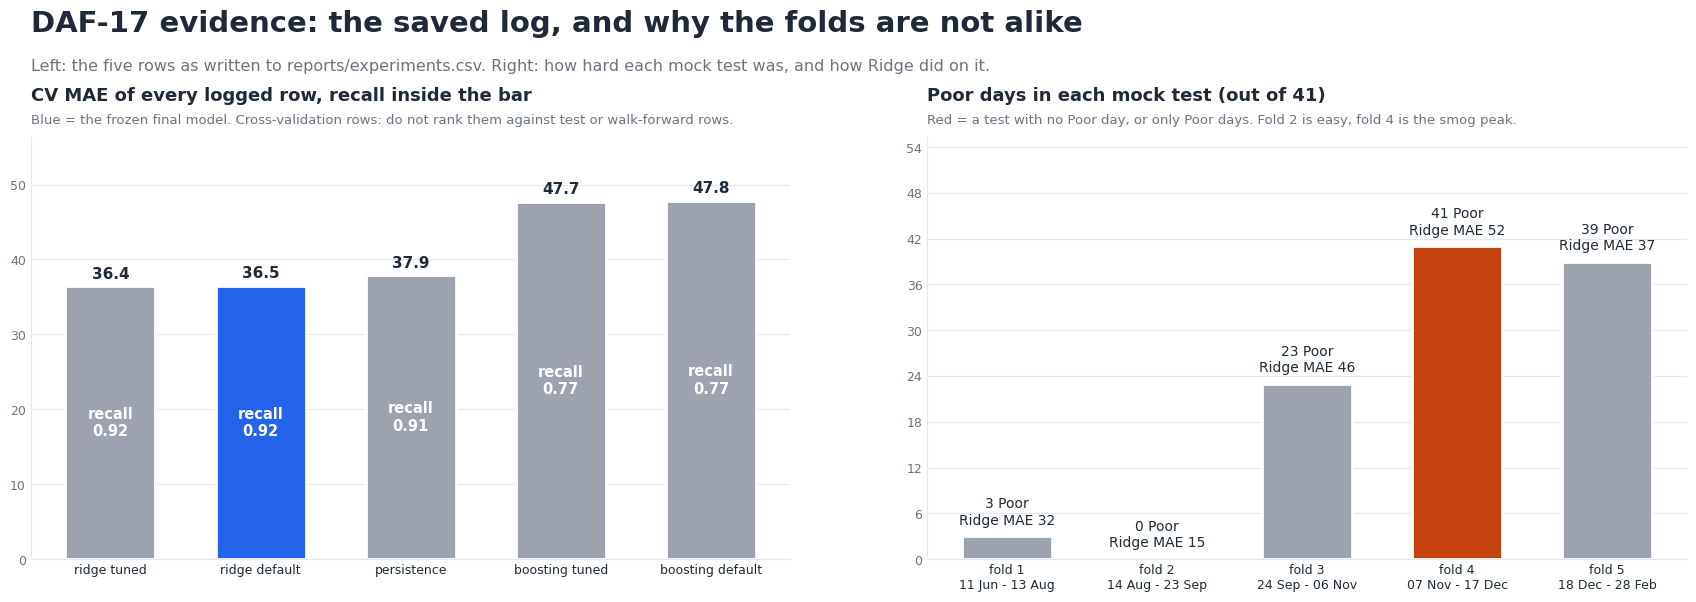

In [11]:
# The evidence figure: the saved log rows, and why the folds are not alike.
root = rs.find_project_root()
saved_log = pd.read_csv(root / "reports/experiments.csv")
daf17_rows = saved_log.loc[saved_log["ticket"] == "DAF-17"].copy()
daf17_rows["label"] = (daf17_rows["model"].str.replace("daf17_", "").str.replace("_cv", "")
                       .str.replace("hgb", "boosting").str.replace("_", " "))
daf17_rows = daf17_rows.sort_values("mae")
assert len(daf17_rows) == 5 and daf17_rows["notes"].str.contains("TimeSeriesSplit").all()

fig = plt.figure(figsize=(rs.FIG_W, 6.6), facecolor="white")
grid = fig.add_gridspec(1, 2, wspace=0.18, left=0.05, right=0.97, top=0.78, bottom=0.14)
rs.header(fig, "DAF-17 evidence: the saved log, and why the folds are not alike",
          "Left: the five rows as written to reports/experiments.csv. Right: how hard each mock test was, and how Ridge did on it.")

log_ax = fig.add_subplot(grid[0, 0])
colors = [rs.ACCENT if label == "ridge default" else rs.BAR for label in daf17_rows["label"]]
bars = log_ax.bar(daf17_rows["label"], daf17_rows["mae"], width=0.6, color=colors, edgecolor="white", linewidth=2)
for bar, (_, row) in zip(bars, daf17_rows.iterrows()):
    log_ax.text(bar.get_x() + bar.get_width() / 2, row["mae"] + 0.7, f"{row['mae']:.1f}", ha="center", va="bottom", fontsize=11, fontweight="bold", color=rs.INK)
    log_ax.text(bar.get_x() + bar.get_width() / 2, row["mae"] / 2, f"recall\n{row['recall_poor']:.2f}", ha="center", va="center", fontsize=10.5, color="white", fontweight="bold")
log_ax.set_ylim(0, daf17_rows["mae"].max() * 1.18)
log_ax.tick_params(axis="x", labelsize=8.5)
rs.style_axis(log_ax, "CV MAE of every logged row, recall inside the bar", "Blue = the frozen final model. Cross-validation rows: do not rank them against test or walk-forward rows.")

hard_ax = fig.add_subplot(grid[0, 1])
poor = folds["poor_days_in_valid"]
bars = hard_ax.bar(list(fold_x), poor, width=0.6, color=[rs.ALERT if p in (0, int(folds["valid_rows"].iloc[0])) else rs.BAR for p in poor], edgecolor="white", linewidth=2)
for bar, p, mae_ in zip(bars, poor, chosen_folds["ridge"]):
    hard_ax.text(bar.get_x() + bar.get_width() / 2, p + 1.2, f"{int(p)} Poor\nRidge MAE {mae_:.0f}", ha="center", va="bottom", fontsize=10, color=rs.INK)
hard_ax.set_xticks(list(fold_x), [f"fold {k}\n{folds.loc[k, 'valid_from']:%d %b} - {folds.loc[k, 'valid_to']:%d %b}" for k in fold_x])
hard_ax.set_ylim(0, poor.max() * 1.35)
rs.whole_numbers(hard_ax)
rs.style_axis(hard_ax, "Poor days in each mock test (out of 41)", "Red = a test with no Poor day, or only Poor days. Fold 2 is easy, fold 4 is the smog peak.")
fig.savefig("figures/17_evidence.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()

### What the recap shows

- **The test days were never touched.** Tuning, comparing and freezing all used the 251 train days. The test days were deleted from memory in Step 1, and an `assert` would stop the notebook if one came back.
- **Honest folds change the picture.** Shuffled `KFold` cheated in 5 of 5 folds. `TimeSeriesSplit` is the only cut that matches how the model will be used.
- **Tuning gave almost nothing, and the rule said so.** 0.047 for Ridge and 0.099 for boosting, against a fold-to-fold swing of tens of µg/m³. The "best of 30" looks better by luck alone.
- **Ridge is final, with a small margin.** It beats persistence by 1.43 µg/m³, wins the three smog folds, and loses the two quiet ones. In recall the two are almost equal (97 against 96 of 106).
- **The freeze is real.** `models/final_config.json` is in git, a model rebuilt from it gives the same marks, and a second run refuses to change it.
- **The evidence is on record.** Five cross-validation rows sit in the experiment log, clearly separate from the test-day and walk-forward rows.

If you remember only one thing: tune on the training days with folds that respect time, write the rule for "was it worth it" before you see the numbers, and freeze the winner before you open the test days.